# π0.5 occlusion features

Colab notebook for one question: which layer-5 transcoder features are about the bowl being painted over, and do those features move the action.

Use an L4 or A100 with high RAM. Run the cells from top to bottom.

1. Controls, Drive, install, caches, and the task-0 demonstrations.
2. Write `scripts/collect_layer5_replay.py`. Later cells import it.
3. Controlled contrasts. This trains the transcoder once and writes `outputs/permanence/controlled_contrasts/`.
4. Occlusion features. Reloads that transcoder. A feature is kept only if it rises for gray paint on the bowl and stays quiet for the same paint off the bowl, for the color swap, and for removing the bowl. The cell then patches those features and compares them with random features and with the color features. Writes `outputs/permanence/occlusion_features/`.

If this runtime already finished step 3, run only the last cell.


In [1]:
# @title Controls

# Shared Drive folder that holds hf_home.tar and the LIBERO archives.
DRIVE_ROOT = "/content/drive/MyDrive/groot-run-shared-programmer908"  # @param {type:"string"}
DRIVE_FOLDER_ID = "13z_Qh91Ww0jdXoju2kQsG12AaEPKZsnH"  # @param {type:"string"}
AUTO_CREATE_DRIVE_SHORTCUT = True  # @param {type:"boolean"}
SHARED_HF_TOKEN_FILE = "secrets/HF_TOKEN.txt"  # @param {type:"string"}

# Pi0.5 does not load on a T4.
REQUIRED_GPU = "A100"  # @param ["L4", "A100", "Any"]
MIN_GPU_MEMORY_GB = 20  # @param {type:"integer"}
MIN_SYSTEM_RAM_GB = 24  # @param {type:"integer"}

# Task. The later cells inherit these.
SUITE = "libero_spatial"  # @param ["libero_spatial", "libero_object", "libero_goal", "libero_10"]
TASK_IDS = "[0]"  # @param {type:"string"}

# Cache. Archive mode avoids copying thousands of small Drive files.
CACHE_TRANSFER_MODE = "archive"  # @param ["archive", "folders"]
ALLOW_AUTH_REFRESH = True  # @param {type:"boolean"}
FORCE_AUTH_REFRESH = False  # @param {type:"boolean"}
HF_OFFLINE = True  # @param {type:"boolean"}

import os
os.environ["SUITE"] = SUITE
os.environ["TASK_IDS"] = TASK_IDS
print("suite", SUITE, "tasks", TASK_IDS)


suite libero_spatial tasks [0]


In [2]:
# @title Mount Drive And Validate Runtime

from pathlib import Path
import os
import subprocess
import time

from google.colab import drive


def parse_gib_from_meminfo() -> int:
    with open("/proc/meminfo", "r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith("MemTotal:"):
                kb = int(line.split()[1])
                return (kb + 1024 * 1024 - 1) // (1024 * 1024)
    return 0


def validate_colab_runtime():
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader,nounits"],
        text=True,
        capture_output=True,
    )
    print(result.stdout or result.stderr)
    if result.returncode != 0:
        raise RuntimeError("No NVIDIA GPU visible. In Colab: Runtime -> Change runtime type -> GPU.")

    gpu_line = result.stdout.strip().splitlines()[0]
    parts = [part.strip() for part in gpu_line.split(",")]
    gpu_name = parts[0]
    gpu_mem_gb = int((int(parts[2]) + 1023) // 1024) if len(parts) >= 3 and parts[2].isdigit() else 0
    system_ram_gb = parse_gib_from_meminfo()
    print(f"Runtime memory: GPU={gpu_name} ~{gpu_mem_gb} GiB VRAM | system RAM ~{system_ram_gb} GiB")

    if REQUIRED_GPU != "Any" and REQUIRED_GPU.lower() not in gpu_name.lower():
        raise RuntimeError(
            f"Requested {REQUIRED_GPU}, but Colab allocated {gpu_name}. "
            "Use Runtime -> Change runtime type -> GPU -> L4/A100, then rerun from this cell."
        )
    if int(MIN_GPU_MEMORY_GB) > 0 and gpu_mem_gb < int(MIN_GPU_MEMORY_GB):
        raise RuntimeError(
            f"GPU VRAM is too small for Pi0.5 LIBERO: {gpu_name} has ~{gpu_mem_gb} GiB, "
            f"need >= {MIN_GPU_MEMORY_GB} GiB. T4 usually exits 137 while loading the policy. "
            "Switch to L4 or A100 before running eval."
        )
    if int(MIN_SYSTEM_RAM_GB) > 0 and system_ram_gb < int(MIN_SYSTEM_RAM_GB):
        raise RuntimeError(
            f"System RAM is too small for Pi0.5 LIBERO: runtime has ~{system_ram_gb} GiB, "
            f"need >= {MIN_SYSTEM_RAM_GB} GiB. In Colab, choose a high-RAM L4/A100 runtime."
        )


validate_colab_runtime()

drive.mount("/content/drive")


def ensure_drive_root_visible(root_value: str) -> Path:
    root = Path(root_value)
    if root.exists():
        return root

    folder_id = str(globals().get("DRIVE_FOLDER_ID", "")).strip()
    auto_shortcut = bool(globals().get("AUTO_CREATE_DRIVE_SHORTCUT", True))
    mydrive_prefixes = ("/content/drive/MyDrive/", "/content/drive/My Drive/")
    if folder_id and auto_shortcut and str(root).startswith(mydrive_prefixes):
        print("Drive root is not visible yet; creating a My Drive shortcut to the shared folder.", flush=True)
        try:
            from google.colab import auth
            auth.authenticate_user()
            try:
                from googleapiclient.discovery import build
            except Exception:
                subprocess.run(["python3", "-m", "pip", "install", "-q", "-U", "google-api-python-client"], check=True)
                from googleapiclient.discovery import build
            service = build("drive", "v3")
            metadata = {
                "name": root.name,
                "mimeType": "application/vnd.google-apps.shortcut",
                "shortcutDetails": {"targetId": folder_id},
                "parents": ["root"],
            }
            created = service.files().create(body=metadata, fields="id,name").execute()
            print(f"Created Drive shortcut: {created.get('name')} ({created.get('id')})", flush=True)
            for _ in range(12):
                if root.exists():
                    return root
                time.sleep(5)
        except Exception as exc:
            raise RuntimeError(
                "Could not auto-create the Drive shortcut. Confirm the folder was shared with this Google account "
                "and DRIVE_FOLDER_ID is the shared folder ID."
            ) from exc
        if root.exists():
            return root
        raise RuntimeError(
            f"Drive shortcut was created, but {root} is not visible in the mounted filesystem yet. "
            "Rerun this cell, or use a Google Workspace Shared Drive path."
        )

    if folder_id and str(root).startswith("/content/drive/Shareddrives/"):
        raise RuntimeError(
            f"Shared Drive path is not visible: {root}. Confirm the teammate has access to the Shared Drive."
        )

    if not folder_id:
        print(
            "DRIVE_FOLDER_ID is blank and DRIVE_ROOT does not exist. Creating a new folder at DRIVE_ROOT; "
            "this is intended only for initial owner setup. For zero teammate setup, set DRIVE_FOLDER_ID in the notebook.",
            flush=True,
        )
    return root


DRIVE_ROOT = ensure_drive_root_visible(DRIVE_ROOT)
DRIVE_ARCHIVES = DRIVE_ROOT / "archives"
DRIVE_HF_HOME = DRIVE_ROOT / "hf_home"
DRIVE_LIBERO_CACHE = DRIVE_ROOT / "libero_cache"
DRIVE_LIBERO_DATASETS = DRIVE_ROOT / "libero_datasets"
DRIVE_OUTPUTS = DRIVE_ROOT / "outputs"
DRIVE_NOTEBOOK_META = DRIVE_ROOT / "notebook_meta"
DRIVE_SECRETS = DRIVE_ROOT / "secrets"
DRIVE_HF_TOKEN_FILE = DRIVE_ROOT / SHARED_HF_TOKEN_FILE
for path in [DRIVE_ROOT, DRIVE_ARCHIVES, DRIVE_HF_HOME, DRIVE_LIBERO_CACHE, DRIVE_LIBERO_DATASETS, DRIVE_OUTPUTS, DRIVE_NOTEBOOK_META, DRIVE_SECRETS]:
    path.mkdir(parents=True, exist_ok=True)

HF_HOME_ARCHIVE = DRIVE_ARCHIVES / "hf_home.tar"
LIBERO_CACHE_ARCHIVE = DRIVE_ARCHIVES / "libero_cache.tar"
LIBERO_DATASETS_ARCHIVE = DRIVE_ARCHIVES / "libero_datasets.tar"

print("Drive root:", DRIVE_ROOT)
print("Archive dir:", DRIVE_ARCHIVES)
print("Optional shared HF token file:", DRIVE_HF_TOKEN_FILE)


NVIDIA A100-SXM4-80GB, 580.82.07, 81920

Runtime memory: GPU=NVIDIA A100-SXM4-80GB ~80 GiB VRAM | system RAM ~168 GiB
Mounted at /content/drive
Drive root: /content/drive/MyDrive/groot-run-shared-programmer908
Archive dir: /content/drive/MyDrive/groot-run-shared-programmer908/archives
Optional shared HF token file: /content/drive/MyDrive/groot-run-shared-programmer908/secrets/HF_TOKEN.txt


In [3]:
# @title Install Native Runtime Equivalent To cloud/libero/Dockerfile

import os
import subprocess
from pathlib import Path

VENV = Path("/content/lerobot-venv")
PYTHON = VENV / "bin/python"
UV_BIN_DIR = Path("/content/uv-bin")
UV = str(UV_BIN_DIR / "uv")


def run(cmd, *, env=None):
    cmd = list(map(str, cmd))
    print("$", " ".join(cmd), flush=True)
    try:
        return subprocess.run(cmd, env=env, check=True)
    except subprocess.CalledProcessError as exc:
        print(f"Command failed with exit code {exc.returncode}: {' '.join(cmd)}", flush=True)
        raise


def install_uv() -> str:
    # Colab may already have /usr/local/bin/uv, but its version/behavior can differ.
    # Use a notebook-owned binary so every clean runtime follows the same path.
    UV_BIN_DIR.mkdir(parents=True, exist_ok=True)
    installer = Path("/tmp/install-uv.sh")
    run(["curl", "-LsSf", "https://astral.sh/uv/install.sh", "-o", installer])
    env = os.environ.copy()
    env["UV_INSTALL_DIR"] = str(UV_BIN_DIR)
    run(["sh", installer], env=env)
    os.environ["PATH"] = f"{UV_BIN_DIR}:" + os.environ["PATH"]
    run([UV, "--version"])
    return UV


apt_packages = [
    "build-essential", "ca-certificates", "cmake", "curl", "ffmpeg", "git", "pv", "rsync",
    "libegl1", "libgl1", "libglib2.0-0", "libglvnd0", "libglx0", "libopengl0",
    "libosmesa6-dev", "libsm6", "libxext6", "libxrender1", "pkg-config",
]
apt_env = os.environ.copy()
apt_env["DEBIAN_FRONTEND"] = "noninteractive"
run(["apt-get", "update", "-qq"], env=apt_env)
run(["apt-get", "install", "-y", "-qq", *apt_packages], env=apt_env)
UV = install_uv()

# Managed Python avoids system-package/venv quirks in Colab images.
run([UV, "python", "install", "3.12"])
run([UV, "venv", "--clear", str(VENV), "--python", "3.12"])

run([
    UV, "pip", "install", "--python", str(PYTHON), "--torch-backend", "cu128",
    "lerobot[evaluation,libero,pi]", "hf-transfer", "opencv-python", "numpy",
])

os.environ["PATH"] = f"{VENV / 'bin'}:{UV_BIN_DIR}:" + os.environ["PATH"]
print("Python:", PYTHON)
run([str(PYTHON), "-c", "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"])


$ apt-get update -qq
$ apt-get install -y -qq build-essential ca-certificates cmake curl ffmpeg git pv rsync libegl1 libgl1 libglib2.0-0 libglvnd0 libglx0 libopengl0 libosmesa6-dev libsm6 libxext6 libxrender1 pkg-config
$ curl -LsSf https://astral.sh/uv/install.sh -o /tmp/install-uv.sh
$ sh /tmp/install-uv.sh
$ /content/uv-bin/uv --version
$ /content/uv-bin/uv python install 3.12
$ /content/uv-bin/uv venv --clear /content/lerobot-venv --python 3.12
$ /content/uv-bin/uv pip install --python /content/lerobot-venv/bin/python --torch-backend cu128 lerobot[evaluation,libero,pi] hf-transfer opencv-python numpy
Python: /content/lerobot-venv/bin/python
$ /content/lerobot-venv/bin/python -c import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')


CompletedProcess(args=['/content/lerobot-venv/bin/python', '-c', "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"], returncode=0)

In [4]:
# @title Local workspace

from pathlib import Path
import os

LOCAL_REPO = Path("/content/groot-run")
LOCAL_REPO.mkdir(parents=True, exist_ok=True)
(LOCAL_REPO / "scripts").mkdir(parents=True, exist_ok=True)
os.environ["LOCAL_REPO"] = str(LOCAL_REPO)
print("Local workspace:", LOCAL_REPO)


Local workspace: /content/groot-run


In [5]:
# @title Prepare Drive Caches And Offline Mode

from pathlib import Path
import os
import shutil
import shlex
import subprocess
import time

LOCAL_HF_HOME = Path("/content/hf_home")
LOCAL_LIBERO_CACHE = Path.home() / ".cache/libero"
LOCAL_OUTPUT_ROOT = LOCAL_REPO / "outputs/eval/pi05_libero"
LOCAL_DATA_ROOT = LOCAL_REPO / "data/libero/datasets"
LOCAL_LIBERO_CONFIG = LOCAL_REPO / ".libero"
for path in [LOCAL_OUTPUT_ROOT, LOCAL_LIBERO_CONFIG]:
    path.mkdir(parents=True, exist_ok=True)

HF_CACHE_REFRESHED = False

repos = ["lerobot/pi05_libero_finetuned", "google/paligemma-3b-pt-224", "lerobot/libero-assets"]


def hf_repo_type(repo_id: str) -> str:
    return "dataset" if repo_id == "lerobot/libero-assets" else "model"


def now_text() -> str:
    return time.strftime("%H:%M:%S")


def format_duration(seconds: float | None) -> str:
    if seconds is None or seconds != seconds or seconds < 0:
        return "unknown"
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f"{hours}h{minutes:02d}m{secs:02d}s"
    if minutes:
        return f"{minutes}m{secs:02d}s"
    return f"{secs}s"


def format_bytes(value: float | int | None) -> str:
    if value is None:
        return "unknown"
    value = float(value)
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f"{value:.1f}{unit}" if unit != "B" else f"{value:.0f}{unit}"
        value /= 1024
    return f"{value:.1f}PiB"


def timed(label, fn):
    print(f"\n== {label} | start {now_text()} ==", flush=True)
    start = time.time()
    result = fn()
    elapsed = time.time() - start
    print(f"== done: {label} | elapsed {format_duration(elapsed)} | finish {now_text()} ==", flush=True)
    return result


def run(cmd, **kwargs):
    print("+", " ".join(map(str, cmd)), flush=True)
    start = time.time()
    result = subprocess.run([str(x) for x in cmd], check=True, **kwargs)
    print(f"+ done in {format_duration(time.time() - start)}", flush=True)
    return result


def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def dir_has_anything(path: Path) -> bool:
    return path.exists() and any(path.iterdir())


def hf_cache_has(repo_id: str, root: Path) -> bool:
    namespace, name = repo_id.split("/", 1)
    prefix = "datasets" if hf_repo_type(repo_id) == "dataset" else "models"
    return (root / "hub" / f"{prefix}--{namespace}--{name}").exists()


def get_hf_token(required: bool = False) -> str:
    token = ""
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN") or ""
        if token:
            print("Using private Colab Secret HF_TOKEN.", flush=True)
            return token
    except Exception:
        pass
    token_file = globals().get("DRIVE_HF_TOKEN_FILE")
    if token_file and Path(token_file).exists():
        token = Path(token_file).read_text().strip()
        if token:
            print(f"Using shared Drive HF token file: {token_file}", flush=True)
            return token
    if required:
        raise RuntimeError(
            "ALLOW_AUTH_REFRESH=True requires either private Colab Secret HF_TOKEN "
            f"or shared Drive token file at {globals().get('DRIVE_HF_TOKEN_FILE', 'DRIVE_ROOT/secrets/HF_TOKEN.txt')}."
        )
    return ""



def path_size_bytes(path: Path) -> int:
    if not path.exists():
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not Path(root, name).is_symlink()]
        for name in files:
            file_path = Path(root, name)
            try:
                total += file_path.lstat().st_size
            except OSError:
                pass
    return total


def du(path: Path):
    if path.exists():
        run(["du", "-sh", path])


def extract_tar(archive: Path, dst: Path):
    reset_dir(dst)
    size = archive.stat().st_size
    print(f"Archive: {archive} ({format_bytes(size)}) -> {dst}", flush=True)
    cmd = f"set -euo pipefail; pv -ptebarf -s {size} {shlex.quote(str(archive))} | tar -C {shlex.quote(str(dst))} -xf -"
    run(["bash", "-lc", cmd])
    du(dst)


def create_tar(src: Path, archive: Path):
    if not dir_has_anything(src):
        print(f"Skipping archive for empty directory: {src}", flush=True)
        return
    archive.parent.mkdir(parents=True, exist_ok=True)
    tmp = archive.with_suffix(archive.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    size_bytes = path_size_bytes(src)
    print(f"Archiving: {src} ({format_bytes(size_bytes)}) -> {archive}", flush=True)
    cmd = f"set -euo pipefail; tar -C {shlex.quote(str(src))} -cf - . | pv -ptebarf -s {size_bytes} > {shlex.quote(str(tmp))}"
    run(["bash", "-lc", cmd])
    tmp.replace(archive)
    run(["ls", "-lh", archive])


def rsync_tree(src: Path, dst: Path, reset: bool = True):
    src.mkdir(parents=True, exist_ok=True)
    if reset:
        reset_dir(dst)
    else:
        dst.mkdir(parents=True, exist_ok=True)
    print(f"Rsync: {src} ({format_bytes(path_size_bytes(src))}) -> {dst}", flush=True)
    run(["rsync", "-a", "--human-readable", "--info=progress2", "--stats", f"{src}/", f"{dst}/"])
    du(dst)


if CACHE_TRANSFER_MODE == "archive" and HF_HOME_ARCHIVE.exists() and not FORCE_AUTH_REFRESH:
    timed("extract HF cache archive from Drive to /content", lambda: extract_tar(HF_HOME_ARCHIVE, LOCAL_HF_HOME))
elif ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=True)
    reset_dir(LOCAL_HF_HOME)
    run([str(PYTHON), "-c", "import huggingface_hub; print('huggingface_hub OK')"])
    refresh_code = """
from huggingface_hub import HfApi, snapshot_download
from huggingface_hub.utils import enable_progress_bars
import os
import subprocess
import threading
import time

repos = os.environ['REFRESH_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'
heartbeat_seconds = int(os.environ.get('HF_PROGRESS_HEARTBEAT_SECONDS', '15'))


def now_text():
    return time.strftime('%H:%M:%S')


def format_duration(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return 'unknown'
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f'{hours}h{minutes:02d}m{secs:02d}s'
    if minutes:
        return f'{minutes}m{secs:02d}s'
    return f'{secs}s'


def format_bytes(value):
    if value is None:
        return 'unknown'
    value = float(value)
    units = ['B', 'KiB', 'MiB', 'GiB', 'TiB']
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f'{value:.1f}{unit}' if unit != 'B' else f'{value:.0f}{unit}'
        value /= 1024
    return f'{value:.1f}PiB'


def path_size_bytes(path):
    if not os.path.exists(path):
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not os.path.islink(os.path.join(root, name))]
        for name in files:
            file_path = os.path.join(root, name)
            try:
                total += os.lstat(file_path).st_size
            except OSError:
                pass
    return total


def estimate_repo_size(api, repo):
    try:
        if repo_type(repo) == 'dataset':
            info = api.dataset_info(repo_id=repo, token=token, files_metadata=True)
        else:
            info = api.model_info(repo_id=repo, token=token, files_metadata=True)
        sizes = [getattr(sibling, 'size', None) for sibling in getattr(info, 'siblings', [])]
        total = sum(size for size in sizes if isinstance(size, int))
        count = len(sizes)
        return count, total or None
    except Exception as exc:
        print(f'[{repo}] could not estimate size before download: {type(exc).__name__}: {exc}', flush=True)
        return None, None


def heartbeat(repo, root, start_bytes, estimated_total, stop_event):
    last_time = time.time()
    last_bytes = start_bytes
    start_time = last_time
    while not stop_event.wait(heartbeat_seconds):
        now = time.time()
        current_bytes = path_size_bytes(root)
        delta = max(0, current_bytes - start_bytes)
        recent_rate = max(0, current_bytes - last_bytes) / max(0.001, now - last_time)
        avg_rate = delta / max(0.001, now - start_time)
        if estimated_total and avg_rate > 0:
            remaining = max(0, estimated_total - delta)
            eta = remaining / avg_rate
            pct = min(100.0, (delta / estimated_total) * 100.0)
            estimate_text = f'{pct:5.1f}% of est. {format_bytes(estimated_total)} | ETA {format_duration(eta)}'
        else:
            estimate_text = 'ETA unknown'
        print(
            f'[{repo}] progress {format_bytes(delta)} | recent {format_bytes(recent_rate)}/s | '
            f'avg {format_bytes(avg_rate)}/s | elapsed {format_duration(now - start_time)} | {estimate_text}',
            flush=True,
        )
        last_time = now
        last_bytes = current_bytes


os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '0'
os.environ['TQDM_DISABLE'] = '0'
os.environ['TQDM_MININTERVAL'] = '1'
try:
    enable_progress_bars()
except Exception as exc:
    print(f'Could not force-enable Hugging Face progress bars: {type(exc).__name__}: {exc}', flush=True)

api = HfApi()
for index, repo in enumerate(repos, 1):
    print(f'\\n[{index}/{len(repos)}] preparing {repo} at {now_text()}', flush=True)
    file_count, estimated_total = estimate_repo_size(api, repo)
    if file_count is not None:
        print(f'[{repo}] estimated remote files={file_count} size={format_bytes(estimated_total)}', flush=True)
    before = path_size_bytes(cache_dir)
    stop_event = threading.Event()
    monitor = threading.Thread(target=heartbeat, args=(repo, cache_dir, before, estimated_total, stop_event), daemon=True)
    start = time.time()
    monitor.start()
    try:
        path = snapshot_download(
            repo_id=repo,
            repo_type=repo_type(repo),
            cache_dir=cache_dir,
            token=token,
            max_workers=8,
        )
    finally:
        stop_event.set()
        monitor.join(timeout=2)
    elapsed = time.time() - start
    after = path_size_bytes(cache_dir)
    delta = max(0, after - before)
    avg_rate = delta / max(0.001, elapsed)
    print(f'[{repo}] -> {path}', flush=True)
    print(
        f'[{repo}] done at {now_text()} | elapsed {format_duration(elapsed)} | '
        f'cache delta {format_bytes(delta)} | avg {format_bytes(avg_rate)}/s | total cache {format_bytes(after)}',
        flush=True,
    )
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token,
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "REFRESH_REPOS": ",".join(repos),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
        "HF_PROGRESS_HEARTBEAT_SECONDS": "15",
    })
    timed("download gated HF models to fast local disk", lambda: subprocess.run([str(PYTHON), "-u", "-c", refresh_code], env=env, check=True))
    HF_CACHE_REFRESHED = True
elif CACHE_TRANSFER_MODE == "folders" or dir_has_anything(DRIVE_HF_HOME):
    print("Archive missing; falling back to Drive folder rsync. This can be very slow for HF caches.", flush=True)
    timed("copy HF cache folder from Drive to /content", lambda: rsync_tree(DRIVE_HF_HOME, LOCAL_HF_HOME))
else:
    raise RuntimeError(
        "No HF cache archive or folder found in Drive. Set ALLOW_AUTH_REFRESH=True once with private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt."
    )

missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]
if missing_local and ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=False)
    refresh_missing_code = """
from huggingface_hub import snapshot_download
import os

repos = os.environ['MISSING_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in repos:
    print('refreshing missing cache entry', repo, 'repo_type', repo_type(repo), flush=True)
    path = snapshot_download(
        repo_id=repo,
        repo_type=repo_type(repo),
        cache_dir=cache_dir,
        token=token,
        max_workers=8,
    )
    print(repo, '->', path, flush=True)
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token or "",
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "MISSING_REPOS": ",".join(missing_local),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
    })
    timed("refresh missing HF cache entries", lambda: subprocess.run([str(PYTHON), "-u", "-c", refresh_missing_code], env=env, check=True))
    HF_CACHE_REFRESHED = True
    missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]

if missing_local:
    raise RuntimeError(
        "Local HF cache is missing: " + ", ".join(missing_local) + "\n"
        "Run once with ALLOW_AUTH_REFRESH=True plus private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt, "
        "or populate DRIVE_ROOT/archives/hf_home.tar."
    )

if CACHE_TRANSFER_MODE == "archive" and LIBERO_CACHE_ARCHIVE.exists():
    timed("extract LIBERO cache archive from Drive", lambda: extract_tar(LIBERO_CACHE_ARCHIVE, LOCAL_LIBERO_CACHE))
else:
    timed("copy LIBERO cache folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_CACHE, LOCAL_LIBERO_CACHE))

if CACHE_TRANSFER_MODE == "archive" and LIBERO_DATASETS_ARCHIVE.exists():
    timed("extract LIBERO datasets archive from Drive", lambda: extract_tar(LIBERO_DATASETS_ARCHIVE, LOCAL_DATA_ROOT))
else:
    timed("copy LIBERO datasets folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_DATASETS, LOCAL_DATA_ROOT))

os.environ.update({
    "PATH": f"{VENV / 'bin'}:" + os.environ["PATH"],
    "PYTHON": str(PYTHON),
    "HF_HOME": str(LOCAL_HF_HOME),
    "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
    "HF_HUB_ENABLE_HF_TRANSFER": "1",
    "HF_XET_HIGH_PERFORMANCE": "1",
    "HF_HUB_DISABLE_PROGRESS_BARS": "0",
    "TQDM_DISABLE": "0",
    "TQDM_MININTERVAL": "1",
    "MUJOCO_GL": "egl",
    "PYOPENGL_PLATFORM": "egl",
    "MUJOCO_EGL_DEVICE_ID": "0",
    "MPLBACKEND": "Agg",
    "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
    "LIBERO_DATASET_DIR": str(LOCAL_DATA_ROOT),
    "OUTPUT_ROOT": str(LOCAL_OUTPUT_ROOT),
})
if HF_OFFLINE:
    os.environ.update({"HF_HUB_OFFLINE": "1", "TRANSFORMERS_OFFLINE": "1", "HF_DATASETS_OFFLINE": "1"})
else:
    os.environ.pop("HF_HUB_OFFLINE", None)
    os.environ.pop("TRANSFORMERS_OFFLINE", None)
    os.environ.pop("HF_DATASETS_OFFLINE", None)

validate_code = """
from huggingface_hub import snapshot_download
import os


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in os.environ['VALIDATE_REPOS'].split(','):
    path = snapshot_download(repo_id=repo, repo_type=repo_type(repo), cache_dir=os.environ['HF_HUB_CACHE'], local_files_only=True)
    print(repo, '->', path, flush=True)
"""
env = os.environ.copy()
env["VALIDATE_REPOS"] = ",".join(repos)
timed("validate local HF cache with local_files_only=True", lambda: subprocess.run([str(PYTHON), "-u", "-c", validate_code], env=env, check=True))

install_assets_code = """
from pathlib import Path
import os
import shutil
import site

from huggingface_hub import snapshot_download

roots = [Path(path) for path in site.getsitepackages()]
user_site = site.getusersitepackages()
if user_site:
    roots.append(Path(user_site))
for root in roots:
    candidate = root / "libero" / "libero"
    if candidate.exists():
        libero_root = candidate
        break
else:
    raise SystemExit("Could not find installed libero package path")

assets_dir = libero_root / "assets"
required = assets_dir / "scenes" / "libero_tabletop_base_style.xml"
snapshot = Path(snapshot_download(
    repo_id="lerobot/libero-assets",
    repo_type="dataset",
    cache_dir=os.environ["HF_HUB_CACHE"],
    local_files_only=True,
))
if not required.exists():
    print(f"Installing LIBERO assets: {snapshot} -> {assets_dir}", flush=True)
    assets_dir.mkdir(parents=True, exist_ok=True)
    for child in snapshot.iterdir():
        if child.name == ".gitattributes":
            continue
        target = assets_dir / child.name
        if child.is_dir():
            shutil.copytree(child, target, dirs_exist_ok=True)
        else:
            shutil.copy2(child, target)
if not required.exists():
    raise SystemExit(f"LIBERO asset install failed; missing {required}")
print("libero_assets OK", required, flush=True)
"""
timed("install LIBERO assets into package", lambda: subprocess.run([str(PYTHON), "-u", "-c", install_assets_code], env=os.environ.copy(), check=True))

print("\nLocal cache summary:")
du(LOCAL_HF_HOME)
du(LOCAL_LIBERO_CACHE)
du(LOCAL_DATA_ROOT)



== extract HF cache archive from Drive to /content | start 03:47:52 ==
Archive: /content/drive/MyDrive/groot-run-shared-programmer908/archives/hf_home.tar (18.2GiB) -> /content/hf_home
+ bash -lc set -euo pipefail; pv -ptebarf -s 19585320960 /content/drive/MyDrive/groot-run-shared-programmer908/archives/hf_home.tar | tar -C /content/hf_home -xf -
+ done in 7m02s
+ du -sh /content/hf_home
+ done in 0s
== done: extract HF cache archive from Drive to /content | elapsed 7m02s | finish 03:54:55 ==

== copy LIBERO cache folder from Drive | start 03:54:55 ==
Rsync: /content/drive/MyDrive/groot-run-shared-programmer908/libero_cache (0B) -> /root/.cache/libero
+ rsync -a --human-readable --info=progress2 --stats /content/drive/MyDrive/groot-run-shared-programmer908/libero_cache/ /root/.cache/libero/
+ done in 0s
+ du -sh /root/.cache/libero
+ done in 0s
== done: copy LIBERO cache folder from Drive | elapsed 0s | finish 03:54:55 ==

== extract LIBERO datasets archive from Drive | start 03:54:55

# Transcoder circuit tracing: fast track (Goals 1–3)

The cells below follow the "minimum viable version" plan. They reuse the setup above (Drive, venv, HF cache, LIBERO) and replace the step 2–4 cells that the intro mentions, which are not in this notebook. Run them top to bottom on one A100 or L4 high-RAM session.

| Cell | What it does | Gate | Rough time on A100 |
|---|---|---|---|
| Plan controls | All knobs from the plan table. Writes `config.json` and the LIBERO config | – | seconds |
| Write pipeline script | `scripts/tc_occlusion.py`: every step runs in the lerobot venv as a subprocess | – | seconds |
| Step 1: probe frames | Task 0, 2 episodes. Picks 2 pre-grasp frames per episode (largest base-vs-occluded gap). Renders base / recolor / absent / occluded / slab_miss / occluded_absent from the simulator, using a segmentation mask of the target bowl | – | ~5 min |
| Validate: checks 1–4 | Edits are clean, determinism, the signal exists, and the ceiling (full layer swap) works. **Run before Goal 1** | Goal 1 refuses to run if any of these fail | ~5 min |
| Transcoders: check 5 | Captures MLP in/out of every LLM layer, then trains one TopK transcoder per layer (512 features, k=16, 400 steps). Reports held-out FVU and a splice test | Goal 1 refuses to run if check 5 fails (switch off with `CHECK5_BLOCKS`) | ~5–10 min |
| Goal 1 | Feature table (layer × feature × score). A feature is kept if it rises for `occluded` and stays quiet for recolor / absent / slab_miss (specificity ≥ 0.5) | Kill switch: no passing feature anywhere, so stop | ~2 min |
| Goal 2 | Patches **only** the occlusion features into the base run (base→occluded), compared against random same-norm features, color features, the full-token swap ceiling and token structure (bowl tokens vs the rest). Also reports single features, the reverse direction and cross-layer edges | Goal 2 fails, so stop (skip Goal 3) | ~5–10 min |
| Goal 3 | Closed-loop LIBERO with the bowl painted out of both cameras on every step: baseline / features ablated / features amplified (+ a clean reference). Check 6 runs first, then paired bootstrap CIs | – | ~5 min at 2 episodes per condition |
| Summary | Every check and goal in one table, plus the pitch line filled in with your numbers | – | seconds |

Notes:
* π0.5's LLM backbone is PaliGemma's Gemma-2B, which has **18** decoder layers, not 32. The notebook finds the layers at runtime and trains one transcoder for every layer it finds.
* "Gap closed %" = `100 × (1 − RMSE(patched, occluded) / RMSE(base, occluded))` on the normalized 50×7 action chunk, with one fixed flow-matching noise tensor per frame.
* Outputs go to `/content/groot-run/outputs/permanence/tc_circuit` and are mirrored to `DRIVE_ROOT/outputs/permanence/tc_circuit`. The large activation cache (`acts/`) is not mirrored.

In [22]:
# @title Plan controls (fast track)

import json
import os
import subprocess
from pathlib import Path

# --- task / policy (inherits SUITE and TASK_IDS from the Controls cell at the top)
POLICY_PATH = "lerobot/pi05_libero_finetuned"  # @param {type:"string"}
TASK_ID = json.loads(TASK_IDS)[0] if isinstance(TASK_IDS, str) else int(TASK_IDS[0])
TARGET_OBJECT = "auto"  # @param {type:"string"}
TARGET_KEYWORD = "bowl"  # @param {type:"string"}
OBS_SIZE = 256  # @param {type:"integer"}

# --- probe frames: 4 frames = 2 episodes x 2 frames
FRAME_SOURCE = "auto"  # @param ["auto", "demo", "rollout"]
N_EPISODES = 2  # @param {type:"integer"}
FRAMES_PER_EPISODE = 2  # @param {type:"integer"}
N_CANDIDATES = 8  # @param {type:"integer"}
FRAME_PICK = "max_gap"  # @param ["max_gap", "even"]
EXTRA_TRAIN_FRAMES_PER_EPISODE = 12  # @param {type:"integer"}
MIN_MASK_PX = 80  # @param {type:"integer"}

# --- image edits (one variable at a time)
PAINT_GRAY = 128  # @param {type:"integer"}
OCC_PAD_PX = 2  # @param {type:"integer"}
SHADOW_PAD_PX = 6  # @param {type:"integer"}

# --- validation thresholds
MIN_GAP = 0.02  # @param {type:"number"}
CEILING_MIN_PCT = 90.0  # @param {type:"number"}
DETERMINISM_TOL = 0.0  # @param {type:"number"}
TC_MAX_FVU = 0.2  # @param {type:"number"}
CHECK5_BLOCKS = True  # @param {type:"boolean"}

# --- transcoders: one TopK transcoder per LLM layer
TC_FEATURES = 512  # @param {type:"integer"}
TC_K = 16  # @param {type:"integer"}
TC_STEPS = 3000  # @param {type:"integer"}
TC_LR = 0.002  # @param {type:"number"}
TC_BATCH = 1024  # @param {type:"integer"}

# --- Goal 1
MIN_SPECIFICITY = 0.5  # @param {type:"number"}
MIN_POS_FRAC = 1.0  # @param {type:"number"}
MIN_RISE_TOKENS = 1.0  # @param {type:"number"}
MAX_FEATURES_PER_LAYER = 8  # @param {type:"integer"}
TOP_LAYERS = 3  # @param {type:"integer"}

# --- Goal 2
N_RANDOM_DRAWS = 5  # @param {type:"integer"}
GOAL2_MARGIN_PTS = 10.0  # @param {type:"number"}

# --- Goal 3 (the plan says 2 runs per condition; raise this if you want a tighter CI)
GOAL3_EPISODES = 2  # @param {type:"integer"}
AMPLIFY_FACTOR = 3.0  # @param {type:"number"}
PREDICTED_DIRECTION = "ablate_up"  # @param ["ablate_up", "ablate_down"]
GOAL3_INCLUDE_CLEAN = True  # @param {type:"boolean"}
GOAL3_MAX_STEPS = 0  # @param {type:"integer"}
SAVE_VIDEOS = True  # @param {type:"boolean"}

# --- misc
FORCE_CONTINUE = False  # @param {type:"boolean"}
SEED = 0  # @param {type:"integer"}

TC_OUT = LOCAL_REPO / "outputs/permanence/tc_circuit"
DRIVE_TC = DRIVE_OUTPUTS / "permanence/tc_circuit"
TC_SCRIPT = LOCAL_REPO / "scripts/tc_occlusion.py"
TC_OUT.mkdir(parents=True, exist_ok=True)
DRIVE_TC.mkdir(parents=True, exist_ok=True)

# Resume after a runtime reset: pull earlier results back from Drive.
if not (TC_OUT / "frames.pkl").exists() and (DRIVE_TC / "frames.pkl").exists():
    print("Restoring earlier tc_circuit results from Drive ...")
    import shutil
    shutil.copytree(DRIVE_TC, TC_OUT, dirs_exist_ok=True)

config = {
    "policy_path": POLICY_PATH, "suite": SUITE, "task_id": int(TASK_ID), "target_object": TARGET_OBJECT,
    "target_keyword": TARGET_KEYWORD, "obs_size": int(OBS_SIZE), "libero_dataset_dir": str(LOCAL_DATA_ROOT),
    "frame_source": FRAME_SOURCE, "n_episodes": int(N_EPISODES), "demo_indices": list(range(int(N_EPISODES))),
    "frames_per_episode": int(FRAMES_PER_EPISODE), "n_candidates": int(N_CANDIDATES), "frame_pick": FRAME_PICK,
    "min_t": 5, "lift_dz": 0.01, "min_frame_spacing": 5, "min_mask_px": int(MIN_MASK_PX),
    "extra_train_frames_per_episode": int(EXTRA_TRAIN_FRAMES_PER_EPISODE),
    "paint_gray": int(PAINT_GRAY), "occ_pad_px": int(OCC_PAD_PX), "shadow_pad_px": int(SHADOW_PAD_PX),
    "recolor_rgb": [200, 40, 40], "token_min_frac": 0.1,
    "clean_edit_max_outside": 0.002, "determinism_tol": float(DETERMINISM_TOL), "min_gap": float(MIN_GAP),
    "ceiling_min_pct": float(CEILING_MIN_PCT), "tc_max_fvu": float(TC_MAX_FVU), "check5_blocks": bool(CHECK5_BLOCKS),
    "tc_layers": "all", "tc_features": int(TC_FEATURES), "tc_k": int(TC_K), "tc_steps": int(TC_STEPS),
    "tc_lr": float(TC_LR), "tc_batch": int(TC_BATCH), "tc_holdout_frac": 0.1, "tc_dead_steps": 50,
    "tc_aux_k": 64, "tc_aux_coef": 1 / 32,
    "min_specificity": float(MIN_SPECIFICITY), "min_pos_frac": float(MIN_POS_FRAC), "min_rise_tokens": float(MIN_RISE_TOKENS),
    "max_features_per_layer": int(MAX_FEATURES_PER_LAYER), "top_layers": int(TOP_LAYERS),
    "n_random_draws": int(N_RANDOM_DRAWS), "goal2_margin_pts": float(GOAL2_MARGIN_PTS),
    "goal3_episodes": int(GOAL3_EPISODES), "amplify_factor": float(AMPLIFY_FACTOR),
    "predicted_direction": PREDICTED_DIRECTION, "goal3_include_clean": bool(GOAL3_INCLUDE_CLEAN),
    "goal3_max_steps": int(GOAL3_MAX_STEPS), "goal3_init_offset": 0, "goal3_layers": "auto",
    "save_videos": bool(SAVE_VIDEOS), "n_bootstrap": 10000, "force_continue": bool(FORCE_CONTINUE), "seed": int(SEED),
}
(TC_OUT / "config.json").write_text(json.dumps(config, indent=2))

# LIBERO asks for its config interactively on first import; write it up front so subprocesses never block.
os.environ["LIBERO_CONFIG_PATH"] = str(LOCAL_LIBERO_CONFIG)
libero_cfg_code = r'''
import importlib.util, os, pathlib, yaml
spec = importlib.util.find_spec("libero.libero")
root = pathlib.Path(list(spec.submodule_search_locations)[0])
cfg_dir = pathlib.Path(os.environ["LIBERO_CONFIG_PATH"]); cfg_dir.mkdir(parents=True, exist_ok=True)
f = cfg_dir / "config.yaml"
if not f.exists():
    yaml.safe_dump({"benchmark_root": str(root), "bddl_files": str(root / "bddl_files"),
                    "init_states": str(root / "init_files"), "datasets": os.environ["LIBERO_DATASET_DIR"],
                    "assets": str(root / "assets")}, open(f, "w"))
print("LIBERO config:", f)
'''
subprocess.run([str(PYTHON), "-c", libero_cfg_code], env=os.environ.copy(), check=True, stdin=subprocess.DEVNULL)
subprocess.run([str(PYTHON), "-c", "import lerobot, transformers, torch, numpy, mujoco; "
                "print('lerobot', lerobot.__version__, '| transformers', transformers.__version__, '| torch', torch.__version__, "
                "'| numpy', numpy.__version__, '| mujoco', mujoco.__version__)"], env=os.environ.copy(), stdin=subprocess.DEVNULL)
print("suite", SUITE, "task", TASK_ID, "| out:", TC_OUT, "| drive mirror:", DRIVE_TC)

suite libero_spatial task 0 | out: /content/groot-run/outputs/permanence/tc_circuit | drive mirror: /content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit


### Write the pipeline script
This cell only writes `scripts/tc_occlusion.py`. Each step below runs one of its subcommands in the lerobot venv (`frames`, `validate`, `capture`, `train`, `goal1`, `goal2`, `goal3`).

In [27]:
%%writefile /content/groot-run/scripts/tc_occlusion.py
#!/usr/bin/env python
"""Transcoder circuit tracing of occlusion features in pi0.5 (LIBERO).

Every subcommand reads <out_dir>/config.json (written by the notebook's controls cell).

  frames    pick the probe frames, render the 6 conditions, save frames.pkl
  validate  checks 1-4 on the unpatched pipeline ("instrument is not broken")
  capture   capture MLP input/output of every LLM layer on every sample
  train     one TopK transcoder per layer + check 5 (faithfulness)
  goal1     do occlusion features exist? (feature table + kill switch)
  goal2     do they cause the action? (patching / circuit-trace table)
  goal3     do they change task success? (closed loop + check 6)
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import os
import pickle
import random
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import numpy as np
import torch
import torch.nn as nn

CONDS = ["base", "recolor", "absent", "occluded", "slab_miss", "occluded_absent"]
QUIET_FOR_OCC = ["recolor", "absent", "slab_miss"]  # the "other 3 contrasts"
QUIET_FOR_COLOR = ["occluded", "absent", "slab_miss"]
CAM_OF_KEY = {"image": "agentview", "image2": "robot0_eye_in_hand"}
ROBOT_PREFIXES = ("robot0_", "gripper0_", "mount0_")

CFG: dict = {}
OUT: Path = Path(".")
DEV = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------------------------------------------------------- utils


def log(*args):
    print(time.strftime("[%H:%M:%S]"), *args, flush=True)


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, torch.Tensor):
        return o.detach().cpu().tolist()
    if isinstance(o, Path):
        return str(o)
    if isinstance(o, (set, tuple)):
        return list(o)
    return str(o)


def save_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_json_default)


def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def write_status(step: str, passed: bool | None, summary: dict):
    save_json(OUT / "status" / f"{step}.json", {"step": step, "passed": passed, "time": time.strftime("%Y-%m-%d %H:%M:%S"), **summary})


def read_status(step: str):
    p = OUT / "status" / f"{step}.json"
    return load_json(p) if p.exists() else None


def require_gate(step: str, what: str):
    st = read_status(step)
    if st is None:
        raise SystemExit(f"[gate] {step} has not been run yet. Run the {step} cell first.")
    if st.get("passed") is False and not CFG.get("force_continue", False):
        raise SystemExit(
            f"[gate] {step} did not pass, so {what} is stopped (plan's gate rule). "
            f"Reason: {st.get('reason', 'see status/' + step + '.json')}. Set FORCE_CONTINUE=True to run anyway."
        )
    return st


def setup_torch(seed: int):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
    warnings.filterwarnings("once")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def rmse(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean((a.float() - b.float()) ** 2)).item())


def closure_pct(a_patch, a_target, a_start) -> float:
    gap = rmse(a_start, a_target)
    if gap <= 0:
        return float("nan")
    return 100.0 * (1.0 - rmse(a_patch, a_target) / gap)


def dilate(mask: np.ndarray, px: int) -> np.ndarray:
    if px <= 0 or not mask.any():
        return mask.copy()
    import cv2

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * px + 1, 2 * px + 1))
    return cv2.dilate(mask.astype(np.uint8), k) > 0


def token_mask(region: np.ndarray, grid: int, min_frac: float) -> np.ndarray:
    """Region in raw (OpenGL) image coords -> (grid*grid,) bool over the model's image tokens.

    The LIBERO processor flips H and W before the policy sees the image, then the image is
    resized to 224 and cut into grid x grid SigLIP patches in row-major order.
    """
    r = region[::-1, ::-1].astype(np.float32)
    H, W = r.shape
    ys = (np.arange(grid + 1) * H / grid).astype(int)
    xs = (np.arange(grid + 1) * W / grid).astype(int)
    out = np.zeros((grid, grid), dtype=bool)
    for i in range(grid):
        for j in range(grid):
            blk = r[ys[i] : ys[i + 1], xs[j] : xs[j + 1]]
            out[i, j] = blk.size > 0 and blk.mean() >= min_frac
    return out.reshape(-1)


def model_view(img: np.ndarray) -> np.ndarray:
    """What the policy sees (after the LIBERO 180-degree flip)."""
    return np.ascontiguousarray(img[::-1, ::-1])


def _add_batch_axis(x):
    if isinstance(x, dict):
        return {k: _add_batch_axis(v) for k, v in x.items()}
    if isinstance(x, np.ndarray):
        return np.ascontiguousarray(x[None])
    return x


def bootstrap_paired_diff(a: np.ndarray, b: np.ndarray, n_boot: int, seed: int):
    """95% CI for mean(a) - mean(b) resampling paired episode indices."""
    rng = np.random.default_rng(seed)
    n = len(a)
    if n == 0:
        return float("nan"), (float("nan"), float("nan"))
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = a[idx].mean(1) - b[idx].mean(1)
    return float(a.mean() - b.mean()), (float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5)))


# ----------------------------------------------------------------------------- image edits


def recolor(img: np.ndarray, mask: np.ndarray, rgb) -> np.ndarray:
    out = img.copy()
    if not mask.any():
        return out
    lum = img[mask].astype(np.float32).mean(axis=1)
    rel = lum / max(float(lum.max()), 1.0)
    shade = 0.35 + 0.65 * rel
    out[mask] = np.clip(shade[:, None] * np.asarray(rgb, np.float32)[None, :], 0, 255).astype(np.uint8)
    return out


def paint(img: np.ndarray, region: np.ndarray, gray: int) -> np.ndarray:
    out = img.copy()
    out[region] = np.uint8(gray)
    return out


def shift_region(region: np.ndarray, forbidden_strict: np.ndarray, forbidden_soft: np.ndarray):
    """Translate `region` to the nearest spot that avoids the object (and, if possible, the robot)."""
    if not region.any():
        return region.copy(), (0, 0), "empty"
    H, W = region.shape
    ys, xs = np.nonzero(region)
    h = ys.max() - ys.min() + 1
    w = xs.max() - xs.min() + 1
    dirs = ((0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1))
    for forbidden, tag in ((forbidden_strict | forbidden_soft, "clear"), (forbidden_strict, "overlaps_robot")):
        for mul in (1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0):
            for dy, dx in dirs:
                sy, sx = int(round(dy * mul * h)), int(round(dx * mul * w))
                ny, nx = ys + sy, xs + sx
                if ny.min() < 0 or nx.min() < 0 or ny.max() >= H or nx.max() >= W:
                    continue
                new = np.zeros_like(region)
                new[ny, nx] = True
                if (new & forbidden).any():
                    continue
                return new, (sy, sx), tag
    return np.zeros_like(region), (0, 0), "no_room"


def make_conditions(base_px: dict, absent_px: dict, masks: dict, robot_masks: dict):
    """Returns conds[cond][key] -> uint8 image and regions[cond][key] -> allowed-change mask."""
    conds = {c: {} for c in CONDS}
    regions = {c: {} for c in CONDS}
    info = {}
    for key, base in base_px.items():
        m = masks[key]
        occ_r = dilate(m, CFG["occ_pad_px"])
        abs_r = dilate(m, CFG["shadow_pad_px"])
        forbid_obj = dilate(m, CFG["shadow_pad_px"] + 2)
        slab_r, shift, tag = shift_region(occ_r, forbid_obj, robot_masks[key])
        absent = np.where(abs_r[..., None], absent_px[key], base).astype(np.uint8)
        g = CFG["paint_gray"]
        conds["base"][key] = base.copy()
        conds["recolor"][key] = recolor(base, m, CFG["recolor_rgb"])
        conds["absent"][key] = absent
        conds["occluded"][key] = paint(base, occ_r, g)
        conds["slab_miss"][key] = paint(base, slab_r, g)
        conds["occluded_absent"][key] = paint(absent, occ_r, g)
        zeros = np.zeros_like(m)
        regions["base"][key] = zeros
        regions["recolor"][key] = m.copy()
        regions["absent"][key] = abs_r
        regions["occluded"][key] = occ_r
        regions["slab_miss"][key] = slab_r
        regions["occluded_absent"][key] = abs_r | occ_r
        info[key] = {"mask_px": int(m.sum()), "occ_px": int(occ_r.sum()), "slab_shift": shift, "slab_tag": tag}
    return conds, regions, info


# ----------------------------------------------------------------------------- simulator side


def libero_task(env):
    return env.task_description


def make_env(episode_index: int = 0):
    from lerobot.envs.libero import LiberoEnv, _get_suite

    suite = _get_suite(CFG["suite"])
    env = LiberoEnv(
        task_suite=suite,
        task_id=int(CFG["task_id"]),
        task_suite_name=CFG["suite"],
        obs_type="pixels_agent_pos",
        observation_width=int(CFG["obs_size"]),
        observation_height=int(CFG["obs_size"]),
        init_states=True,
        episode_index=episode_index,
    )
    ensure_sim(env)
    return env


def ensure_sim(env):
    """Newer lerobot builds the LIBERO sim lazily (on first reset / _ensure_env); make sure it exists."""
    if getattr(env, "_env", None) is None:
        if callable(getattr(env, "_ensure_env", None)):
            env._ensure_env()
        else:
            env.reset(seed=int(CFG.get("seed", 0)))
    if getattr(env, "_env", None) is None:
        raise RuntimeError("LiberoEnv did not create its simulator (env._env is None).")
    return env


def _bddl_lists(env):
    """obj_of_interest / goal objects / declared objects, from every place LIBERO keeps them."""
    import re

    inner = getattr(env._env, "env", None)
    ooi, goal, objs = [], [], []
    try:
        ooi = [str(o) for o in (env._env.obj_of_interest or [])]
    except Exception:
        pass
    pp = getattr(inner, "parsed_problem", None) or {}
    if not ooi:
        ooi = [str(o) for o in (pp.get("obj_of_interest") or [])]
    for pred in pp.get("goal_state") or []:
        if isinstance(pred, (list, tuple)):
            goal += [str(t) for t in pred[1:] if isinstance(t, str)]
    try:
        objs = [str(k) for k in inner.objects_dict.keys()]
    except Exception:
        pass
    text = ""
    for cand in (getattr(inner, "bddl_file_name", None), getattr(env._env, "bddl_file_name", None)):
        if cand and os.path.exists(str(cand)):
            text = Path(str(cand)).read_text()
            break
    if not text:
        try:
            from libero.libero import get_libero_path

            from lerobot.envs.libero import _get_suite

            task = _get_suite(CFG["suite"]).get_task(int(CFG["task_id"]))
            if task is not None:
                f = Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
                text = f.read_text() if f.exists() else ""
        except Exception:
            pass
    if text:
        m = re.search(r"\(:obj_of_interest([^()]*)\)", text)
        if m and not ooi:
            ooi = m.group(1).split()
        g = re.search(r"\(:goal(.*)", text, re.S)
        if g and not goal:
            goal = re.findall(r"\(\s*\w+\s+([\w]+)(?:\s+([\w]+))?\s*\)", g.group(1))
            goal = [t for pair in goal for t in pair if t]
    return ooi, goal, objs


def infer_target(env):
    kw = str(CFG.get("target_keyword", "")).strip()
    ooi, goal, objs = _bddl_lists(env)
    explicit = str(CFG.get("target_object", "auto")).strip()
    if explicit and explicit != "auto":
        return explicit, ooi, "TARGET_OBJECT"
    for name, cands in (("obj_of_interest", ooi), ("BDDL goal", goal), ("scene objects", sorted(objs))):
        hit = [o for o in cands if kw in o and (not objs or o in objs)]
        if hit:
            return hit[0], ooi, name
    import mujoco

    m = env._env.sim.model._model
    bodies = sorted({mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(m.nbody)})
    hit = [b for b in bodies if kw in b and not b.startswith(ROBOT_PREFIXES)]
    if hit:
        root = hit[0]
        for suffix in ("_main", "_body", "_base"):
            if root.endswith(suffix):
                root = root[: -len(suffix)]
        return root, ooi, "MuJoCo body names"
    raise RuntimeError(
        f"Could not infer the target object for keyword {kw!r}. obj_of_interest={ooi} goal={goal} objects={objs}. "
        "Set TARGET_OBJECT in the Plan controls cell (e.g. akita_black_bowl_1)."
    )


class Scene:
    """Object bookkeeping + rendering helpers on top of the LIBERO robosuite sim.

    robosuite's hard reset (LIBERO default) builds a new MjSim on every env.reset(), so every
    public method re-binds to the live sim first.
    """

    def __init__(self, env):
        import mujoco

        self.mj = mujoco
        self.env = ensure_sim(env)
        self._sim = None
        self.size = int(CFG["obs_size"])
        target, ooi, how = infer_target(env)
        self.target = target
        self.obj_of_interest = ooi
        log(f"target object {target!r} (found via {how})")
        self._refresh()
        log(f"target object: {target} | bodies={len(self.body_ids)} geoms={len(self.geom_ids)} free_joints={len(self.free_joints)} | obj_of_interest={ooi}")

    def _refresh(self):
        ensure_sim(self.env)
        sim = self.env._env.sim
        if sim is self._sim:
            return
        mujoco = self.mj
        self._sim = sim
        self.sim = sim
        self.m = sim.model._model
        self.d = sim.data._data
        target = self.target
        names = [mujoco.mj_id2name(self.m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(self.m.nbody)]
        self.body_names = names

        def subtree(pred):
            out = set()
            for b in range(self.m.nbody):
                a = b
                while a > 0:
                    if pred(names[a]):
                        out.add(b)
                        break
                    a = int(self.m.body_parentid[a])
            return out

        self.body_ids = subtree(lambda n: n == target or n.startswith(target + "_"))
        if not self.body_ids:
            hint = sorted({n.rsplit("_", 1)[0] for n in names if n and not n.startswith(ROBOT_PREFIXES)})
            raise RuntimeError(f"No MuJoCo bodies found for target object {target!r}. Body-name stems in this scene: {hint}")
        self.geom_ids = np.array([g for g in range(self.m.ngeom) if int(self.m.geom_bodyid[g]) in self.body_ids], dtype=np.int64)
        robot_bodies = subtree(lambda n: n.startswith(ROBOT_PREFIXES))
        self.robot_geom_ids = np.array([g for g in range(self.m.ngeom) if int(self.m.geom_bodyid[g]) in robot_bodies], dtype=np.int64)
        self.free_joints = [
            (int(self.m.jnt_qposadr[j]), int(self.m.jnt_bodyid[j]))
            for j in range(self.m.njnt)
            if int(self.m.jnt_bodyid[j]) in self.body_ids and int(self.m.jnt_type[j]) == int(mujoco.mjtJoint.mjJNT_FREE)
        ]
        self.root_body = self.free_joints[0][1] if self.free_joints else min(self.body_ids)

    # --- rendering
    def rgb(self, cam: str) -> np.ndarray:
        self._refresh()
        return np.array(self.sim.render(camera_name=cam, width=self.size, height=self.size), copy=True)

    def seg(self, cam: str) -> np.ndarray:
        """(H, W, 2) [objtype, objid]. Own decoder: robosuite 1.4's overflows under numpy 2."""
        self._refresh()
        mj = self.mj
        ctx = self.sim._render_context_offscreen
        cid = mj.mj_name2id(self.m, mj.mjtObj.mjOBJ_CAMERA, cam)
        W = H = self.size
        ctx.render(width=W, height=H, camera_id=cid, segmentation=True)
        buf = np.empty((H, W, 3), dtype=np.uint8)
        mj.mjr_readPixels(rgb=buf, depth=None, viewport=mj.MjrRect(0, 0, W, H), con=ctx.con)
        code = buf[..., 0].astype(np.int64) + (buf[..., 1].astype(np.int64) << 8) + (buf[..., 2].astype(np.int64) << 16)
        ng = ctx.scn.ngeom
        code[code >= ng + 1] = 0
        table = np.full((ng + 1, 2), -1, dtype=np.int64)
        for i in range(ng):
            g = ctx.scn.geoms[i]
            if g.segid != -1:
                table[g.segid + 1] = (g.objtype, g.objid)
        return table[code]

    def geom_mask(self, seg: np.ndarray, ids: np.ndarray) -> np.ndarray:
        return (seg[..., 0] == int(self.mj.mjtObj.mjOBJ_GEOM)) & np.isin(seg[..., 1], ids)

    def masks(self, cams):
        self._refresh()
        out, robot = {}, {}
        for key, cam in cams.items():
            s = self.seg(cam)
            out[key] = self.geom_mask(s, self.geom_ids)
            robot[key] = self.geom_mask(s, self.robot_geom_ids)
        return out, robot

    def render_absent(self, cams: dict):
        """Render with the target object moved out of view; restore the exact state afterwards."""
        self._refresh()
        mj = self.mj
        q = self.d.qpos.copy()
        v = self.d.qvel.copy()
        rgba = None
        if self.free_joints:
            for i, (adr, _) in enumerate(self.free_joints):
                self.d.qpos[adr : adr + 3] = np.array([60.0 + 5 * i, 60.0, -30.0])
        else:  # fixed object: make it transparent instead
            rgba = self.m.geom_rgba[self.geom_ids].copy()
            self.m.geom_rgba[self.geom_ids, 3] = 0.0
        mj.mj_forward(self.m, self.d)
        imgs = {key: self.rgb(cam) for key, cam in cams.items()}
        leftover = {key: int(self.geom_mask(self.seg(cam), self.geom_ids).sum()) for key, cam in cams.items()}
        self.d.qpos[:] = q
        self.d.qvel[:] = v
        if rgba is not None:
            self.m.geom_rgba[self.geom_ids] = rgba
        mj.mj_forward(self.m, self.d)
        assert np.array_equal(self.d.qpos, q), "state restore failed"
        return imgs, leftover

    def set_state_fast(self, state):
        self._refresh()
        self.env._env.sim.set_state_from_flattened(state)
        self.mj.mj_forward(self.m, self.d)

    def object_z(self) -> float:
        self._refresh()
        return float(self.d.xpos[self.root_body][2])


def render_frame(env, scene: Scene, state: np.ndarray) -> dict:
    raw = env._env.set_init_state(state)
    fmt = env._format_raw_obs(raw)
    keys = list(fmt["pixels"].keys())
    cams = {k: CAM_OF_KEY[k] for k in keys}
    base_px, render_diff = {}, {}
    for k in keys:
        base_px[k] = np.ascontiguousarray(fmt["pixels"][k]).copy()
        render_diff[k] = int(np.abs(scene.rgb(cams[k]).astype(int) - base_px[k].astype(int)).max())
    absent_px, leftover = scene.render_absent(cams)
    try:
        masks, robot = scene.masks(cams)
        mask_src = "segmentation"
    except Exception as exc:  # fall back to "what changes when the object is removed"
        log(f"segmentation render failed ({type(exc).__name__}: {exc}); using removal-diff masks")
        masks = {k: (np.abs(absent_px[k].astype(int) - base_px[k].astype(int)).max(-1) > 12) for k in keys}
        robot = {k: np.zeros_like(masks[k]) for k in keys}
        mask_src = "removal_diff"
    conds, regions, info = make_conditions(base_px, absent_px, masks, robot)
    return {
        "state": np.asarray(state).copy(),
        "robot_state": fmt["robot_state"],
        "conds": conds,
        "regions": regions,
        "masks": masks,
        "robot_masks": robot,
        "edit_info": info,
        "render_diff": render_diff,
        "absent_leftover_px": leftover,
        "mask_source": mask_src,
    }


def fmt_obs(frame: dict, cond: str) -> dict:
    return {"pixels": frame["conds"][cond], "robot_state": frame["robot_state"]}


def occlude_live_obs(obs: dict, scene: Scene) -> dict:
    """Closed loop: paint the target object gray in every camera, every step."""
    cams = {k: CAM_OF_KEY[k] for k in obs["pixels"].keys()}
    masks, _ = scene.masks(cams)
    px = {}
    for k, img in obs["pixels"].items():
        px[k] = paint(np.ascontiguousarray(img), dilate(masks[k], CFG["occ_pad_px"]), CFG["paint_gray"])
    out = dict(obs)
    out["pixels"] = px
    return out


# ----------------------------------------------------------------------------- policy side


class Stack:
    def __init__(self):
        from lerobot.configs.policies import PreTrainedConfig
        from lerobot.envs.configs import LiberoEnv as LiberoEnvConfig
        from lerobot.envs.factory import make_env_pre_post_processors
        from lerobot.policies.factory import make_policy, make_pre_post_processors

        path = CFG["policy_path"]
        pcfg = PreTrainedConfig.from_pretrained(path)
        pcfg.pretrained_path = path
        pcfg.device = "cuda"
        if getattr(pcfg, "compile_model", False):
            # torch.compile (max-autotune = CUDA graphs) reuses output buffers and bakes the graph,
            # which breaks forward hooks / patching. Interpretability needs eager mode.
            log("checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)")
            pcfg.compile_model = False
        ecfg = LiberoEnvConfig(task=CFG["suite"], task_ids=[int(CFG["task_id"])])
        t0 = time.time()
        self.policy = make_policy(cfg=pcfg, env_cfg=ecfg)
        self.policy.eval()
        disable_compile(self.policy.model)
        self.pre, self.post = make_pre_post_processors(
            policy_cfg=pcfg,
            pretrained_path=path,
            preprocessor_overrides={
                "device_processor": {"device": "cuda"},
                "rename_observations_processor": {"rename_map": {}},
            },
        )
        self.env_pre, self.env_post = make_env_pre_post_processors(env_cfg=ecfg, policy_cfg=pcfg)
        self.config = self.policy.config
        log(f"policy loaded in {time.time() - t0:.0f}s | dtype={getattr(self.config, 'dtype', '?')} "
            f"chunk={self.config.chunk_size} n_action_steps={self.config.n_action_steps} "
            f"image_features={list(self.config.image_features)}")

    def batch(self, obs: dict, task: str) -> dict:
        from lerobot.envs.utils import preprocess_observation

        o = preprocess_observation(_add_batch_axis(obs))
        o["task"] = [task]
        o = self.env_pre(o)
        o = self.pre(o)
        return o

    def noise(self, seed: int) -> torch.Tensor:
        g = torch.Generator().manual_seed(int(seed))
        shape = (1, int(self.config.chunk_size), int(self.config.max_action_dim))
        return torch.randn(shape, generator=g, dtype=torch.float32).to(DEV)

    def img_keys(self, batch: dict):
        keys = [k for k in self.config.image_features if k in batch]
        keys += [k for k in self.config.image_features if k not in batch]
        return keys


def disable_compile(model):
    """Drop instance-level torch.compile wrappers (sample_actions / forward) so the model runs eagerly."""
    removed = []
    for name in ("sample_actions", "forward", "denoise_step", "embed_prefix"):
        fn = model.__dict__.get(name)
        if fn is not None and (hasattr(fn, "_torchdynamo_orig_callable") or "compile" in type(fn).__name__.lower()
                               or "OptimizedModule" in type(fn).__name__):
            del model.__dict__[name]
            removed.append(name)
    if removed:
        log(f"removed torch.compile wrappers: {removed}")
    try:
        import torch._dynamo

        torch._dynamo.reset()
    except Exception:
        pass
    return removed


def _find_lm_layers(model):
    pwe = model.paligemma_with_expert
    cands = []
    for getter in (
        lambda: pwe.paligemma.language_model.layers,
        lambda: pwe.paligemma.model.language_model.layers,
        lambda: pwe.paligemma.language_model.model.layers,
    ):
        try:
            layers = getter()
            if isinstance(layers, nn.ModuleList) and len(layers) > 0:
                return layers
        except Exception:
            pass
    for name, mod in pwe.paligemma.named_modules():
        if name.endswith("language_model.layers") and isinstance(mod, nn.ModuleList):
            cands.append(mod)
    if cands:
        return cands[0]
    raise RuntimeError("Could not find the PaliGemma language-model decoder layers.")


class Runner:
    """Forward hooks on every LLM (PaliGemma/Gemma-2B) decoder layer and its MLP.

    Hooks only fire during the prefix pass (images + prompt); the action expert has its own layers.
    """

    def __init__(self, stack: Stack):
        self.stack = stack
        self.policy = stack.policy
        self.model = stack.policy.model
        self.layers = _find_lm_layers(self.model)
        self.n_layers = len(self.layers)
        self.capture = None
        self.capture_layers: set = set()
        self.mlp_patch: dict = {}
        self.resid_patch: dict = {}
        self.persistent_mlp_patch: dict = {}
        self.last_prefix: dict = {}
        self.mlp_calls = 0
        orig = self.model.embed_prefix

        def wrapped(*args, **kwargs):
            embs, pad, att = orig(*args, **kwargs)
            images = args[0] if len(args) > 0 else kwargs["images"]
            tokens = args[2] if len(args) > 2 else kwargs["tokens"]
            self.last_prefix = {
                "pad": pad[0].detach().bool().clone(),
                "n_img": len(images),
                "lang_len": int(tokens.shape[1]),
                "T": int(embs.shape[1]),
                "tokens": tokens[0].detach().cpu().clone(),
            }
            return embs, pad, att

        self.model.embed_prefix = wrapped
        for i, layer in enumerate(self.layers):
            layer.mlp.register_forward_hook(self._mlp_hook(i), with_kwargs=True)
            layer.register_forward_hook(self._layer_hook(i))
        log(f"hooked {self.n_layers} LLM decoder layers (MLP + residual output)")

    def _mlp_hook(self, i):
        def hook(mod, args, kwargs, output):
            self.mlp_calls += 1
            x = args[0] if args else next(iter(kwargs.values()))
            if self.capture is not None and i in self.capture_layers:
                self.capture[("mlp_in", i)] = x.detach()
                self.capture[("mlp_out", i)] = output.detach()
            fn = self.mlp_patch.get(i) or self.persistent_mlp_patch.get(i)
            if fn is not None:
                return fn(x, output).to(output.dtype)
            return None

        return hook

    def _layer_hook(self, i):
        def hook(mod, inputs, output):
            h = output[0] if isinstance(output, tuple) else output
            if self.capture is not None and i in self.capture_layers:
                self.capture[("resid", i)] = h.detach()
            fn = self.resid_patch.get(i)
            if fn is not None:
                h2 = fn(h).to(h.dtype)
                return (h2,) + tuple(output[1:]) if isinstance(output, tuple) else h2
            return None

        return hook

    @torch.no_grad()
    def run(self, batch, noise, capture_layers=None, mlp_patch=None, resid_patch=None):
        self.capture = {} if capture_layers is not None else None
        self.capture_layers = set(capture_layers or [])
        self.mlp_patch = mlp_patch or {}
        self.resid_patch = resid_patch or {}
        try:
            actions = self.policy.predict_action_chunk(batch, noise=noise.clone())
        finally:
            cap = self.capture
            self.capture = None
            self.capture_layers = set()
            self.mlp_patch = {}
            self.resid_patch = {}
        return actions.detach().float()[0], cap

    # token layout ---------------------------------------------------------------
    def layout(self, batch):
        lp = self.last_prefix
        n_img, lang_len, T = lp["n_img"], lp["lang_len"], lp["T"]
        if (T - lang_len) % n_img:
            log(f"WARNING: prefix has {T - lang_len} non-language tokens, not divisible by {n_img} images")
        per_img = (T - lang_len) // n_img
        grid = int(round(math.sqrt(per_img)))
        keys = self.stack.img_keys(batch)
        suffix = [k.split(".")[-1] for k in keys]
        return {"n_img": n_img, "lang_len": lang_len, "T": T, "per_img": per_img, "grid": grid, "img_keys": keys, "img_suffix": suffix}

    def bowl_positions(self, layout, frame) -> torch.Tensor:
        T = layout["T"]
        m = torch.zeros(T, dtype=torch.bool)
        for i, suf in enumerate(layout["img_suffix"]):
            if suf in frame["regions"]["occluded"]:
                tm = token_mask(frame["regions"]["occluded"][suf], layout["grid"], CFG["token_min_frac"])
                idx = np.nonzero(tm)[0] + i * layout["per_img"]
                m[torch.as_tensor(idx, dtype=torch.long)] = True
        return m


# ----------------------------------------------------------------------------- transcoder


class TopKTranscoder(nn.Module):
    """MLP-input -> MLP-output transcoder with TopK sparsity (inputs/outputs mean-centred, unit mean norm)."""

    def __init__(self, d_in: int, d_out: int, n_feat: int, k: int):
        super().__init__()
        self.d_in, self.d_out, self.n_feat, self.k = d_in, d_out, n_feat, k
        self.W_enc = nn.Parameter(torch.empty(d_in, n_feat))
        self.b_enc = nn.Parameter(torch.zeros(n_feat))
        self.W_dec = nn.Parameter(torch.empty(n_feat, d_out))
        self.b_dec = nn.Parameter(torch.zeros(d_out))
        self.register_buffer("x_mean", torch.zeros(d_in))
        self.register_buffer("y_mean", torch.zeros(d_out))
        self.register_buffer("x_scale", torch.ones(()))
        self.register_buffer("y_scale", torch.ones(()))

    def init_weights(self, seed: int):
        g = torch.Generator().manual_seed(seed)
        W = torch.randn(self.n_feat, self.d_out, generator=g)
        W = W / W.norm(dim=1, keepdim=True)
        self.W_dec.data.copy_(W)
        if self.d_in == self.d_out:
            self.W_enc.data.copy_(W.t())
        else:
            self.W_enc.data.copy_(torch.randn(self.d_in, self.n_feat, generator=g) / math.sqrt(self.d_in))

    def pre(self, x):
        xn = (x.float() - self.x_mean) / self.x_scale
        return xn @ self.W_enc + self.b_enc

    def encode(self, x):
        z = self.pre(x)
        v, i = z.topk(self.k, dim=-1)
        return torch.zeros_like(z).scatter_(-1, i, torch.relu(v))

    def decode(self, f):
        return (f @ self.W_dec + self.b_dec) * self.y_scale + self.y_mean

    def delta(self, df, idx=None):
        W = self.W_dec if idx is None else self.W_dec[idx]
        return (df @ W) * self.y_scale


def train_transcoder(x: torch.Tensor, y: torch.Tensor, seed: int, device=None):
    device = device or DEV
    n = x.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_hold = max(256, int(CFG["tc_holdout_frac"] * n))
    hold, train = perm[:n_hold], perm[n_hold:]
    xt = x[train].to(device).float()
    yt = y[train].to(device).float()
    xh = x[hold].to(device).float()
    yh = y[hold].to(device).float()
    tc = TopKTranscoder(x.shape[1], y.shape[1], int(CFG["tc_features"]), int(CFG["tc_k"])).to(device)
    tc.init_weights(seed)
    with torch.no_grad():
        tc.x_mean.copy_(xt.mean(0))
        tc.y_mean.copy_(yt.mean(0))
        tc.x_scale.copy_(((xt - tc.x_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
        tc.y_scale.copy_(((yt - tc.y_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
        # scale the encoder so the initial reconstruction has roughly the target norm (1 after normalisation)
        xs0 = xt[: min(4096, len(xt))]
        rec0 = (tc.encode(xs0) @ tc.W_dec).norm(dim=-1).mean()
        tc.W_enc.data /= rec0.clamp_min(1e-6)
    opt = torch.optim.Adam(tc.parameters(), lr=float(CFG["tc_lr"]), betas=(0.9, 0.999))
    steps, bs = int(CFG["tc_steps"]), int(CFG["tc_batch"])
    since_fired = torch.zeros(tc.n_feat, device=device)
    gd = torch.Generator(device=device).manual_seed(seed)
    hist = []
    for step in range(steps):
        lr_mult = min(1.0, (step + 1) / max(1, steps // 20)) * (1.0 if step < 0.8 * steps else max(0.05, (steps - step) / (0.2 * steps)))
        for pg in opt.param_groups:
            pg["lr"] = float(CFG["tc_lr"]) * lr_mult
        idx = torch.randint(0, xt.shape[0], (bs,), generator=gd, device=device)
        xb = xt[idx]
        yb = (yt[idx] - tc.y_mean) / tc.y_scale
        z = tc.pre(xb)
        v, i = z.topk(tc.k, dim=-1)
        f = torch.zeros_like(z).scatter(-1, i, torch.relu(v))
        yhat = f @ tc.W_dec + tc.b_dec
        mse = ((yhat - yb) ** 2).sum(-1).mean()
        loss = mse
        fired = (f > 0).any(0)
        since_fired = torch.where(fired, torch.zeros_like(since_fired), since_fired + 1)
        dead = since_fired > int(CFG["tc_dead_steps"])
        n_dead = int(dead.sum())
        if n_dead > 0 and CFG["tc_aux_coef"] > 0:
            ka = min(int(CFG["tc_aux_k"]), n_dead)
            zd = z.masked_fill(~dead[None, :], float("-inf"))
            va, ia = zd.topk(ka, dim=-1)
            fa = torch.zeros_like(z).scatter(-1, ia, torch.relu(va))
            resid = (yb - yhat).detach()
            ehat = fa @ tc.W_dec
            aux = ((ehat - resid) ** 2).sum(-1).mean() / (resid ** 2).sum(-1).mean().clamp_min(1e-8)
            loss = loss + float(CFG["tc_aux_coef"]) * aux
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        with torch.no_grad():
            tc.W_dec.data /= tc.W_dec.data.norm(dim=1, keepdim=True).clamp_min(1e-8)
        if step % 50 == 0 or step == steps - 1:
            hist.append({"step": step, "loss": float(mse.item()), "dead": n_dead})
    tc.eval()

    @torch.no_grad()
    def evaluate(xx, yy):
        out = []
        for s in range(0, xx.shape[0], 8192):
            out.append(tc.decode(tc.encode(xx[s : s + 8192])))
        yhat = torch.cat(out)
        fvu = float(((yhat - yy) ** 2).sum() / ((yy - yy.mean(0)) ** 2).sum().clamp_min(1e-12))
        nmse = float((((yhat - yy) / tc.y_scale) ** 2).sum(-1).mean())
        return fvu, nmse

    fvu_h, nmse_h = evaluate(xh, yh)
    fvu_t, nmse_t = evaluate(xt[: min(len(xt), 50000)], yt[: min(len(yt), 50000)])
    with torch.no_grad():
        fires = torch.zeros(tc.n_feat, device=device)
        for s in range(0, xt.shape[0], 8192):
            fires += (tc.encode(xt[s : s + 8192]) > 0).float().sum(0)
    metrics = {
        "fvu_heldout": fvu_h, "loss_heldout": nmse_h, "fvu_train": fvu_t, "loss_train": nmse_t,
        "alive_features": int((fires > 0).sum()), "n_train_tokens": int(len(train)), "n_heldout_tokens": int(n_hold),
        "history": hist,
    }
    return tc.cpu(), metrics


def load_tc(layer: int, device=None) -> TopKTranscoder:
    device = device or DEV
    ck = torch.load(OUT / "transcoders" / f"layer_{layer:02d}.pt", map_location="cpu", weights_only=False)
    c = ck["config"]
    tc = TopKTranscoder(c["d_in"], c["d_out"], c["n_feat"], c["k"])
    tc.load_state_dict(ck["state_dict"])
    tc.requires_grad_(False)
    return tc.to(device).eval()


# ----------------------------------------------------------------------------- patch functions


def fp_set(tc, feats, target_f, token_mask=None, norm_match=None, runner=None):
    """Set features `feats` to their values in `target_f` (T, n_feat); keeps the transcoder error term."""
    idx = torch.as_tensor(list(feats), dtype=torch.long, device=target_f.device)

    def fn(x, y):
        f_live = tc.encode(x[0])
        df = target_f[:, idx] - f_live[:, idx]
        d = tc.delta(df, idx)
        if norm_match is not None:
            n = d.norm(dim=-1, keepdim=True)
            d = torch.where(n > 1e-8, d / n.clamp_min(1e-8) * norm_match[:, None], torch.zeros_like(d))
        if token_mask is not None:
            d = d * token_mask[:, None].to(d.dtype)
        return (y[0].float() + d)[None]

    return fn


def fp_scale(tc, feats, alpha: float, runner: Runner):
    """Multiply features by alpha on every valid prefix token (alpha=0 ablates)."""
    idx = torch.as_tensor(list(feats), dtype=torch.long, device=DEV)

    def fn(x, y):
        f_live = tc.encode(x[0])
        d = tc.delta((alpha - 1.0) * f_live[:, idx], idx)
        pad = runner.last_prefix.get("pad")
        if pad is not None and pad.shape[0] == d.shape[0]:
            d = d * pad[:, None].to(d.dtype)
        return (y[0].float() + d)[None]

    return fn


def fp_swap(target_y, token_mask):
    def fn(x, y):
        m = token_mask[:, None]
        return torch.where(m, target_y[0].to(y.dtype), y[0]).float()[None]

    return fn


def rp_swap(target_h, token_mask):
    def fn(h):
        m = token_mask[:, None]
        return torch.where(m, target_h[0].to(h.dtype), h[0])[None]

    return fn


def fp_splice(tc, token_mask):
    """Replace the MLP output with the transcoder's reconstruction (no error term)."""

    def fn(x, y):
        rec = tc.decode(tc.encode(x[0]))
        return torch.where(token_mask[:, None], rec, y[0].float())[None]

    return fn


# ----------------------------------------------------------------------------- plotting


def _plt():
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    return plt


def fig_conditions(frames, path: Path, key="image"):
    plt = _plt()
    n = len(frames)
    fig, axes = plt.subplots(n, len(CONDS), figsize=(2.2 * len(CONDS), 2.3 * n), squeeze=False)
    for r, fr in enumerate(frames):
        for c, cond in enumerate(CONDS):
            ax = axes[r][c]
            ax.imshow(model_view(fr["conds"][cond][key]))
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(cond, fontsize=9)
            if c == 0:
                ax.set_ylabel(f"{fr.get('episode', '?')}\nt={fr.get('t', '?')}", fontsize=8)
    fig.suptitle(f"Probe frames x conditions ({key}, as the policy sees it)", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=110)
    plt.close(fig)


# ----------------------------------------------------------------------------- data I/O


def load_frames():
    with open(OUT / "frames.pkl", "rb") as f:
        return pickle.load(f)


def task_of(fr_data):
    return fr_data["task"]


def find_demo_file(task_name: str):
    roots = [Path(os.environ.get("LIBERO_DATASET_DIR", "")), Path(CFG.get("libero_dataset_dir", ""))]
    for root in roots:
        if root and root.exists():
            hits = sorted(root.rglob(f"{task_name}_demo.hdf5"))
            if hits:
                return hits[0]
    return None


# ============================================================================= steps


def rollout_states(env, scene, stack, init_id: int, seed: int):
    env.init_state_id = init_id
    stack.policy.reset()
    torch.manual_seed(seed)
    obs, _ = env.reset(seed=seed)
    states, success = [], False
    for t in range(int(env._max_episode_steps)):
        states.append(np.asarray(env._env.get_sim_state()).copy())
        batch = stack.batch(obs, libero_task(env))
        with torch.inference_mode():
            act = stack.policy.select_action(batch)
        act = stack.post(act)
        act = stack.env_post({"action": act})["action"]
        obs, _, term, _, info = env.step(act.detach().to("cpu").numpy()[0])
        if term:
            success = bool(info.get("is_success", False))
            break
    return np.stack(states), success


def cmd_frames():
    setup_torch(CFG["seed"])
    stack = Stack()
    runner = Runner(stack)
    env = make_env(0)
    scene = Scene(env)
    task = libero_task(env)
    log(f"task: {task}")

    episodes = []
    src = CFG["frame_source"]
    if src in ("auto", "demo"):
        path = find_demo_file(env.task)
        if path is None:
            msg = f"no demo file {env.task}_demo.hdf5 under LIBERO_DATASET_DIR"
            if src == "demo":
                raise SystemExit(msg)
            log(msg + " -> falling back to policy rollouts")
        else:
            try:
                import h5py
            except ImportError:
                h5py = None
            log(f"demo file: {path}")
            try:
                if h5py is None:
                    raise ImportError("h5py is not installed in the venv")
                with h5py.File(path, "r") as f:
                    names = sorted(f["data"].keys(), key=lambda s: int(s.split("_")[-1]))
                    for di in CFG["demo_indices"][: CFG["n_episodes"]]:
                        nm = names[int(di)]
                        episodes.append({"name": f"demo:{nm}", "states": np.array(f["data"][nm]["states"])})
            except Exception as exc:
                if src == "demo":
                    raise
                log(f"could not read demos ({type(exc).__name__}: {exc}) -> falling back to policy rollouts")
                episodes = []
            ref = np.asarray(env._env.get_sim_state())
            if episodes and episodes[0]["states"].shape[1] != ref.shape[0]:
                log(f"demo state dim {episodes[0]['states'].shape[1]} != sim state dim {ref.shape[0]} -> using rollouts")
                episodes = []
    if not episodes:
        for ep in range(int(CFG["n_episodes"])):
            states, ok = rollout_states(env, scene, stack, init_id=ep, seed=CFG["seed"] + ep)
            log(f"rollout init_state={ep}: {len(states)} steps, success={ok}")
            episodes.append({"name": f"rollout:init{ep}", "states": states, "success": ok})

    probe, extra, cand_rows = [], [], []
    frame_counter = 0
    for ei, ep in enumerate(episodes):
        S = ep["states"]
        zs = []
        for s in S:
            scene.set_state_fast(s)
            zs.append(scene.object_z())
        zs = np.array(zs)
        z0 = float(np.median(zs[: max(3, min(10, len(zs)))]))
        lifted = np.nonzero(zs > z0 + float(CFG["lift_dz"]))[0]
        t_lift = int(lifted[0]) if len(lifted) else len(S)
        t_lo = int(CFG["min_t"])
        t_hi = max(t_lo + 1, t_lift - 3)
        cand_ts = sorted(set(np.linspace(t_lo, t_hi - 1, int(CFG["n_candidates"])).round().astype(int).tolist()))
        log(f"{ep['name']}: T={len(S)} lift at t={t_lift} -> candidates {cand_ts}")
        scored = []
        for t in cand_ts:
            fr = render_frame(env, scene, S[t])
            fr.update({"episode": ep["name"], "t": int(t)})
            mpx = fr["edit_info"]["image"]["mask_px"]
            row = {"episode": ep["name"], "t": int(t), "mask_px_agentview": mpx,
                   "mask_px_wrist": fr["edit_info"].get("image2", {}).get("mask_px", 0)}
            if mpx < int(CFG["min_mask_px"]):
                row["gap"] = None
                row["note"] = "object too small/invisible"
                cand_rows.append(row)
                continue
            fr["noise_seed"] = int(CFG["seed"] + 7919 * (ei + 1) + t)
            noise = stack.noise(fr["noise_seed"])
            a_b, _ = runner.run(stack.batch(fmt_obs(fr, "base"), task), noise)
            a_o, _ = runner.run(stack.batch(fmt_obs(fr, "occluded"), task), noise)
            row["gap"] = rmse(a_b, a_o)
            cand_rows.append(row)
            scored.append((row["gap"], t, fr))
            log(f"  t={t:4d} mask_px={mpx:5d} base-vs-occluded RMSE={row['gap']:.4f}")
        if CFG["frame_pick"] == "max_gap":
            scored.sort(key=lambda r: -r[0])
        chosen = []
        for gap, t, fr in scored:
            if all(abs(t - c[1]) >= int(CFG["min_frame_spacing"]) for c in chosen):
                chosen.append((gap, t, fr))
            if len(chosen) == int(CFG["frames_per_episode"]):
                break
        if len(chosen) < int(CFG["frames_per_episode"]):
            log(f"WARNING: only {len(chosen)} usable probe frames in {ep['name']}")
        for gap, t, fr in sorted(chosen, key=lambda r: r[1]):
            fr["frame_id"] = frame_counter
            frame_counter += 1
            probe.append(fr)
        chosen_ts = {c[1] for c in chosen}
        n_extra = int(CFG["extra_train_frames_per_episode"])
        if n_extra > 0:
            ts = np.linspace(0, len(S) - 1, n_extra + 2).round().astype(int)[1:-1]
            for t in ts:
                if int(t) in chosen_ts:
                    continue
                raw = env._env.set_init_state(S[int(t)])
                fmt = env._format_raw_obs(raw)
                extra.append({"episode": ep["name"], "t": int(t), "robot_state": fmt["robot_state"],
                              "conds": {"base": {k: np.ascontiguousarray(v).copy() for k, v in fmt["pixels"].items()}}})

    data = {
        "task": task,
        "task_name": env.task,
        "target_object": scene.target,
        "obj_of_interest": scene.obj_of_interest,
        "probe": probe,
        "extra": extra,
        "episodes": [{"name": e["name"], "T": int(len(e["states"])), "success": e.get("success")} for e in episodes],
        "candidates": cand_rows,
    }
    with open(OUT / "frames.pkl", "wb") as f:
        pickle.dump(data, f)
    save_json(OUT / "frames_candidates.json", cand_rows)
    fig_conditions(probe, OUT / "fig_probe_conditions_agentview.png", "image")
    if probe and "image2" in probe[0]["conds"]["base"]:
        fig_conditions(probe, OUT / "fig_probe_conditions_wrist.png", "image2")
    summary = {
        "n_probe_frames": len(probe),
        "probe": [{"frame_id": p["frame_id"], "episode": p["episode"], "t": p["t"], "edit_info": p["edit_info"],
                   "mask_source": p["mask_source"]} for p in probe],
        "n_extra_train_frames": len(extra),
        "target_object": scene.target,
    }
    ok = len(probe) >= 1
    write_status("frames", ok, {**summary, "reason": "" if ok else "no usable probe frames"})
    log(f"saved {len(probe)} probe frames and {len(extra)} extra transcoder-training frames")
    env.close()


def cmd_validate():
    setup_torch(CFG["seed"])
    data = load_frames()
    frames, task = data["probe"], data["task"]
    stack = Stack()
    runner = Runner(stack)
    res = {"frames": []}

    # ---- check 1: edits are clean
    c1_rows, c1_ok = [], True
    for fr in frames:
        base = fr["conds"]["base"]
        for cond in CONDS[1:]:
            for key in base:
                img = fr["conds"][cond][key]
                changed = np.abs(img.astype(int) - base[key].astype(int)).max(-1) > 0
                allowed = fr["regions"][cond][key]
                outside = float((changed & ~allowed).mean())
                inside = int((changed & allowed).sum())
                row = {"frame": fr["frame_id"], "cond": cond, "camera": key, "frac_changed_outside": outside, "changed_inside_px": inside}
                if outside >= float(CFG["clean_edit_max_outside"]):
                    c1_ok = False
                if key == "image" and inside == 0:
                    row["warning"] = "edit changed nothing in agentview"
                    c1_ok = False
                c1_rows.append(row)
    # state + prompt identical across conditions
    state_same, tokens_same = True, True
    batches = {}
    for fr in frames:
        bs = {c: stack.batch(fmt_obs(fr, c), task) for c in CONDS}
        batches[fr["frame_id"]] = bs
        ref = bs["base"]
        for c in CONDS[1:]:
            if not torch.equal(bs[c]["observation.state"], ref["observation.state"]):
                state_same = False
            tk = [k for k in ref if "tokens" in k]
            for k in tk:
                if not torch.equal(bs[c][k], ref[k]):
                    tokens_same = False
    render_ok = all(max(fr["render_diff"].values()) == 0 for fr in frames)
    leftover = max(max(fr["absent_leftover_px"].values()) for fr in frames)
    c1_ok = c1_ok and state_same and tokens_same and leftover == 0
    res["check1"] = {
        "passed": c1_ok, "max_frac_changed_outside": max(r["frac_changed_outside"] for r in c1_rows),
        "robot_state_identical": state_same, "prompt_tokens_identical": tokens_same,
        "env_pixels_equal_direct_render": render_ok, "absent_render_leftover_px": leftover,
        "mask_sources": sorted({fr["mask_source"] for fr in frames}), "rows": c1_rows,
    }
    log(f"check 1 (edits clean): {'PASS' if c1_ok else 'FAIL'} | max outside={res['check1']['max_frac_changed_outside']:.5f} "
        f"| state identical={state_same} | prompt identical={tokens_same} | absent leftover px={leftover}")

    # ---- check 2: determinism
    c2 = []
    acts = {}
    for fr in frames:
        noise = stack.noise(fr["noise_seed"])
        b = batches[fr["frame_id"]]
        a1, _ = runner.run(b["base"], noise)
        a2, _ = runner.run(b["base"], noise)
        a3, _ = runner.run(b["occluded"], noise)
        a4, _ = runner.run(b["occluded"], noise)
        d = max(float((a1 - a2).abs().max()), float((a3 - a4).abs().max()))
        c2.append(d)
        acts[fr["frame_id"]] = {c: runner.run(b[c], noise)[0] for c in CONDS}
    c2_ok = max(c2) <= float(CFG["determinism_tol"])
    res["check2"] = {"passed": c2_ok, "max_abs_diff": max(c2), "per_frame": c2}
    log(f"check 2 (determinism): {'PASS' if c2_ok else 'FAIL'} | max diff = {max(c2):.3e}")

    # ---- check 3: the signal exists
    rows3 = []
    for fr in frames:
        A = acts[fr["frame_id"]]
        other_noise = stack.noise(fr["noise_seed"] + 1)
        a_seed, _ = runner.run(batches[fr["frame_id"]]["base"], other_noise)
        row = {"frame": fr["frame_id"], "gap_occluded": rmse(A["base"], A["occluded"]), "seed_noise_rmse": rmse(A["base"], a_seed)}
        for c in CONDS[1:]:
            row[f"rmse_{c}"] = rmse(A["base"], A[c])
        rows3.append(row)
    gaps = [r["gap_occluded"] for r in rows3]
    c3_ok = min(gaps) >= float(CFG["min_gap"])
    res["check3"] = {"passed": c3_ok, "min_gap": min(gaps), "mean_gap": float(np.mean(gaps)), "rows": rows3}
    log(f"check 3 (signal exists): {'PASS' if c3_ok else 'FAIL'} | base-vs-occluded RMSE per frame = "
        + ", ".join(f"{g:.4f}" for g in gaps) + f" (need >= {CFG['min_gap']})")
    for r in rows3:
        log("   frame {frame}: occluded {gap_occluded:.4f} | recolor {rmse_recolor:.4f} | absent {rmse_absent:.4f} | "
            "slab_miss {rmse_slab_miss:.4f} | occ_absent {rmse_occluded_absent:.4f} | other-noise-seed {seed_noise_rmse:.4f}".format(**r))

    # ---- check 4: the ceiling works (full layer-output swap base -> occluded)
    L = runner.n_layers
    per_layer_resid = np.zeros((len(frames), L))
    per_layer_mlp = np.zeros((len(frames), L))
    for fi, fr in enumerate(frames):
        b = batches[fr["frame_id"]]
        noise = stack.noise(fr["noise_seed"])
        a_occ, cap = runner.run(b["occluded"], noise, capture_layers=list(range(L)))
        a_base = acts[fr["frame_id"]]["base"]
        valid = runner.last_prefix["pad"]
        for li in range(L):
            a_r, _ = runner.run(b["base"], noise, resid_patch={li: rp_swap(cap[("resid", li)], valid)})
            a_m, _ = runner.run(b["base"], noise, mlp_patch={li: fp_swap(cap[("mlp_out", li)], valid)})
            per_layer_resid[fi, li] = closure_pct(a_r, a_occ, a_base)
            per_layer_mlp[fi, li] = closure_pct(a_m, a_occ, a_base)
        del cap
    mean_r = per_layer_resid.mean(0)
    mean_m = per_layer_mlp.mean(0)
    c4_ok = float(mean_r.max()) >= float(CFG["ceiling_min_pct"])
    res["check4"] = {"passed": c4_ok, "n_layers": L, "best_layer": int(mean_r.argmax()), "best_pct": float(mean_r.max()),
                     "resid_swap_pct_mean": mean_r.tolist(), "mlp_swap_pct_mean": mean_m.tolist(),
                     "resid_swap_pct_per_frame": per_layer_resid.tolist(), "mlp_swap_pct_per_frame": per_layer_mlp.tolist()}
    log(f"check 4 (ceiling): {'PASS' if c4_ok else 'FAIL'} | best full-layer swap = {mean_r.max():.1f}% at layer {int(mean_r.argmax())} "
        f"(need >= {CFG['ceiling_min_pct']}%)")
    log("   layer : resid-swap % | mlp-swap %")
    for li in range(L):
        log(f"   {li:5d} : {mean_r[li]:8.1f}     | {mean_m[li]:8.1f}")
    plt = _plt()
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.plot(range(L), mean_r, marker="o", label="full layer-output swap (check 4)")
    ax.plot(range(L), mean_m, marker="s", label="MLP-output swap (transcoder site)")
    ax.axhline(float(CFG["ceiling_min_pct"]), color="gray", ls="--", lw=1)
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("gap closed (%)")
    ax.set_title("Ceiling: base -> occluded swaps")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_check4_ceiling.png", dpi=120)
    plt.close(fig)

    passed = c1_ok and c2_ok and c3_ok and c4_ok
    failed = [n for n, ok in (("1", c1_ok), ("2", c2_ok), ("3", c3_ok), ("4", c4_ok)) if not ok]
    save_json(OUT / "validate.json", res)
    write_status("validate", passed, {
        "check1": c1_ok, "check2": c2_ok, "check3": c3_ok, "check4": c4_ok,
        "n_layers": L, "ceiling_best_pct": float(mean_r.max()), "ceiling_best_layer": int(mean_r.argmax()),
        "gaps": gaps, "reason": "" if passed else f"check(s) {','.join(failed)} failed",
    })


def all_samples(data):
    samples = []
    for fr in data["probe"]:
        for c in CONDS:
            samples.append({"kind": "probe", "frame_id": fr["frame_id"], "cond": c, "noise_seed": fr["noise_seed"], "ref": fr})
    for i, ex in enumerate(data["extra"]):
        samples.append({"kind": "extra", "frame_id": -1 - i, "cond": "base", "noise_seed": CFG["seed"] + 31 * (i + 1), "ref": ex})
    return samples


def cmd_capture():
    setup_torch(CFG["seed"])
    data = load_frames()
    stack = Stack()
    runner = Runner(stack)
    L = runner.n_layers
    samples = all_samples(data)
    xs = [[] for _ in range(L)]
    ys = [[] for _ in range(L)]
    sid, pos = [], []
    meta_samples, layout = [], None
    t0 = time.time()
    for si, s in enumerate(samples):
        obs = {"pixels": s["ref"]["conds"][s["cond"]], "robot_state": s["ref"]["robot_state"]}
        b = stack.batch(obs, data["task"])
        _, cap = runner.run(b, stack.noise(s["noise_seed"]), capture_layers=list(range(L)))
        if layout is None:
            layout = runner.layout(b)
        valid = runner.last_prefix["pad"].nonzero().flatten()
        for li in range(L):
            xs[li].append(cap[("mlp_in", li)][0, valid].to(torch.bfloat16).cpu())
            ys[li].append(cap[("mlp_out", li)][0, valid].to(torch.bfloat16).cpu())
        sid.append(torch.full((len(valid),), si, dtype=torch.int32))
        pos.append(valid.cpu().to(torch.int32))
        meta_samples.append({"i": si, "kind": s["kind"], "frame_id": s["frame_id"], "cond": s["cond"], "n_tokens": int(len(valid))})
        del cap
        if si % 8 == 0:
            log(f"captured {si + 1}/{len(samples)} samples ({time.time() - t0:.0f}s)")
    acts = OUT / "acts"
    acts.mkdir(parents=True, exist_ok=True)
    sid = torch.cat(sid)
    pos = torch.cat(pos)
    for li in range(L):
        torch.save({"x": torch.cat(xs[li]), "y": torch.cat(ys[li]), "sample": sid, "pos": pos}, acts / f"layer_{li:02d}.pt")
    layout = {k: v for k, v in layout.items()}
    save_json(acts / "meta.json", {"samples": meta_samples, "layout": layout, "n_layers": L, "n_tokens": int(len(sid))})
    log(f"saved activations for {L} layers, {len(samples)} samples, {len(sid)} tokens -> {acts}")
    write_status("capture", True, {"n_layers": L, "n_samples": len(samples), "n_tokens": int(len(sid)), "layout": layout})


def cmd_train():
    setup_torch(CFG["seed"])
    meta = load_json(OUT / "acts" / "meta.json")
    L = meta["n_layers"]
    layers = list(range(L)) if CFG["tc_layers"] == "all" else [int(v) for v in CFG["tc_layers"]]
    (OUT / "transcoders").mkdir(parents=True, exist_ok=True)
    metrics = {}
    for li in layers:
        t0 = time.time()
        d = torch.load(OUT / "acts" / f"layer_{li:02d}.pt", weights_only=False)
        tc, m = train_transcoder(d["x"], d["y"], seed=CFG["seed"] + li)
        m["seconds"] = time.time() - t0
        metrics[li] = m
        torch.save({"state_dict": tc.state_dict(), "config": {"d_in": tc.d_in, "d_out": tc.d_out, "n_feat": tc.n_feat, "k": tc.k},
                    "layer": li, "metrics": m}, OUT / "transcoders" / f"layer_{li:02d}.pt")
        log(f"layer {li:2d}: held-out FVU={m['fvu_heldout']:.4f} loss={m['loss_heldout']:.4f} alive={m['alive_features']}/{tc.n_feat} "
            f"({m['seconds']:.0f}s)")
        del d
        torch.cuda.empty_cache()

    # ---- check 5: faithful? (a) reconstruction error, (b) splice the transcoder into the model
    data = load_frames()
    stack = Stack()
    runner = Runner(stack)
    splice = {li: [] for li in layers}
    tcs = {li: load_tc(li) for li in layers}
    for fr in data["probe"]:
        noise = stack.noise(fr["noise_seed"])
        bb = stack.batch(fmt_obs(fr, "base"), data["task"])
        bo = stack.batch(fmt_obs(fr, "occluded"), data["task"])
        a_b, _ = runner.run(bb, noise)
        a_o, _ = runner.run(bo, noise)
        gap = max(rmse(a_b, a_o), 1e-8)
        valid = runner.last_prefix["pad"]
        for li in layers:
            a_s, _ = runner.run(bb, noise, mlp_patch={li: fp_splice(tcs[li], valid)})
            splice[li].append(rmse(a_s, a_b) / gap)
    fvus = [metrics[li]["fvu_heldout"] for li in layers]
    med = float(np.median(fvus))
    c5_ok = med <= float(CFG["tc_max_fvu"])
    rows = [{"layer": li, **{k: v for k, v in metrics[li].items() if k != "history"},
             "splice_rmse_over_gap": float(np.mean(splice[li]))} for li in layers]
    save_json(OUT / "train.json", {"rows": rows, "histories": {li: metrics[li]["history"] for li in layers}})
    log(f"check 5 (transcoder faithful): {'PASS' if c5_ok else 'FAIL'} | median held-out FVU={med:.4f} (need <= {CFG['tc_max_fvu']})")
    log("   layer | FVU(held-out) | splice RMSE / occlusion gap")
    for r in rows:
        log(f"   {r['layer']:5d} | {r['fvu_heldout']:12.4f} | {r['splice_rmse_over_gap']:8.3f}")
    plt = _plt()
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
    ax[0].bar(layers, fvus)
    ax[0].axhline(float(CFG["tc_max_fvu"]), color="gray", ls="--", lw=1)
    ax[0].set_title("Held-out FVU per layer")
    ax[0].set_xlabel("layer")
    ax[1].bar(layers, [r["splice_rmse_over_gap"] for r in rows])
    ax[1].axhline(1.0, color="gray", ls="--", lw=1)
    ax[1].set_title("Splice error / occlusion gap (lower is better)")
    ax[1].set_xlabel("layer")
    fig.tight_layout()
    fig.savefig(OUT / "fig_check5_transcoders.png", dpi=120)
    plt.close(fig)
    write_status("train", c5_ok, {"check5": c5_ok, "median_fvu": med, "fvu_per_layer": fvus,
                                  "splice_over_gap": [r["splice_rmse_over_gap"] for r in rows],
                                  "reason": "" if c5_ok else f"median held-out FVU {med:.3f} > {CFG['tc_max_fvu']}"})


def _feature_stats(A, frame_ids, cond_idx, target, quiet):
    """A: dict (frame, cond) -> (n_feat,) summed activation."""
    d = {c: np.stack([A[(f, c)] - A[(f, "base")] for f in frame_ids]) for c in CONDS[1:]}  # (F, n)
    d_t = d[target]
    t_mean = d_t.mean(0)
    pos_frac = (d_t > 0).mean(0)
    other = np.max(np.stack([np.abs(d[c]).mean(0) for c in quiet]), axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        spec = np.where(t_mean > 0, 1.0 - other / np.maximum(t_mean, 1e-12), -np.inf)
    return d, t_mean, pos_frac, other, spec


def cmd_goal1():
    require_gate("validate", "Goal 1")
    if CFG.get("check5_blocks", False):
        require_gate("train", "Goal 1")
    if not (OUT / "acts" / "meta.json").exists():
        raise SystemExit("[gate] activation cache (acts/) is missing, probably after a runtime reset. "
                         "Re-run the Transcoders cell (capture + train) first.")
    setup_torch(CFG["seed"])
    meta = load_json(OUT / "acts" / "meta.json")
    L = meta["n_layers"]
    layers = sorted(int(p.stem.split("_")[1]) for p in (OUT / "transcoders").glob("layer_*.pt"))
    samples = meta["samples"]
    probe_ids = sorted({s["frame_id"] for s in samples if s["kind"] == "probe"})
    rows, selected = [], {}
    contact = {}
    for li in layers:
        tc = load_tc(li)
        d = torch.load(OUT / "acts" / f"layer_{li:02d}.pt", weights_only=False)
        x, sid, pos = d["x"], d["sample"].long(), d["pos"].long()
        n = tc.n_feat
        A = torch.zeros(len(samples), n, dtype=torch.float64)
        fire_cnt = torch.zeros(n, dtype=torch.float64)
        fire_sum = torch.zeros(n, dtype=torch.float64)
        F_keep = {}
        with torch.no_grad():
            for s in range(0, x.shape[0], 8192):
                F = tc.encode(x[s : s + 8192].to(DEV)).double().cpu()
                A.index_add_(0, sid[s : s + 8192], F)
                fire_cnt += (F > 0).sum(0)
                fire_sum += F.sum(0)
                F_keep[s] = F.float().to_sparse()
        typical = (fire_sum / fire_cnt.clamp_min(1)).numpy()
        alive = (fire_cnt > 0).numpy()
        Ad = {}
        for s in samples:
            if s["kind"] == "probe":
                Ad[(s["frame_id"], s["cond"])] = A[s["i"]].numpy()
        dd, occ_mean, pos_frac, other, spec = _feature_stats(Ad, probe_ids, None, "occluded", QUIET_FOR_OCC)
        rise = occ_mean / np.maximum(typical, 1e-8)
        passed = (occ_mean > 0) & (pos_frac >= float(CFG["min_pos_frac"])) & (spec >= float(CFG["min_specificity"])) & (rise >= float(CFG["min_rise_tokens"])) & alive
        score = np.zeros(n)
        score[passed] = spec[passed] * rise[passed]
        _, col_mean, col_pos, col_other, col_spec = _feature_stats(Ad, probe_ids, None, "recolor", QUIET_FOR_COLOR)
        col_rise = col_mean / np.maximum(typical, 1e-8)
        col_score = np.where((col_mean > 0) & alive, np.clip(col_spec, -10, 1) * col_rise, -np.inf)
        for j in range(n):
            rows.append({
                "layer": li, "feature": j, "alive": bool(alive[j]), "typical_act": float(typical[j]),
                "d_occluded": float(occ_mean[j]), "d_occluded_min": float(dd["occluded"][:, j].min()),
                "d_recolor": float(dd["recolor"][:, j].mean()), "d_absent": float(dd["absent"][:, j].mean()),
                "d_slab_miss": float(dd["slab_miss"][:, j].mean()), "d_occluded_absent": float(dd["occluded_absent"][:, j].mean()),
                "frames_positive": float(pos_frac[j]), "specificity": float(spec[j]) if np.isfinite(spec[j]) else None,
                "rise_tokens": float(rise[j]), "score": float(score[j]), "pass": bool(passed[j]),
                "color_specificity": float(col_spec[j]) if np.isfinite(col_spec[j]) else None,
            })
        occ_feats = [int(j) for j in np.argsort(-score) if passed[j]][: int(CFG["max_features_per_layer"])]
        n_color = max(1, len(occ_feats))
        col_order = [int(j) for j in np.argsort(-col_score) if np.isfinite(col_score[j]) and j not in occ_feats]
        color_feats = col_order[:n_color]
        changed = [int(j) for j in range(n) if alive[j] and np.abs(np.stack([dd[c][:, j] for c in CONDS[1:]])).max() > 0]
        selected[li] = {
            "occ": occ_feats, "color": color_feats, "n_pass": int(passed.sum()),
            "score_sum": float(np.sort(score)[::-1][: int(CFG["max_features_per_layer"])].sum()),
            "alive": [int(j) for j in np.nonzero(alive)[0]], "changed": changed,
            "occ_stats": [{"feature": j, "specificity": float(spec[j]), "rise_tokens": float(rise[j]), "d_occluded": float(occ_mean[j])} for j in occ_feats],
        }
        # token maps for the contact sheet (first probe frame, agentview)
        if occ_feats:
            lay = meta["layout"]
            f0 = probe_ids[0]
            cam_i = lay["img_suffix"].index("image") if "image" in lay["img_suffix"] else 0
            lo, hi = cam_i * lay["per_img"], (cam_i + 1) * lay["per_img"]
            maps = {}
            F_all = torch.cat([F_keep[k].to_dense() for k in sorted(F_keep)])
            for s in samples:
                if s["kind"] == "probe" and s["frame_id"] == f0:
                    sel = (sid == s["i"]) & (pos >= lo) & (pos < hi)
                    idx = sel.nonzero().flatten()
                    Fm = F_all[idx][:, occ_feats[:4]]
                    grid = np.zeros((len(occ_feats[:4]), lay["per_img"]), dtype=np.float32)
                    grid[:, (pos[idx] - lo).numpy()] = Fm.t().numpy()
                    maps[s["cond"]] = grid.reshape(len(occ_feats[:4]), lay["grid"], lay["grid"])
            contact[li] = {"features": occ_feats[:4], "maps": maps}
            del F_all
        log(f"layer {li:2d}: {int(passed.sum()):3d} passing occlusion features | top {occ_feats[:8]} | color set {color_feats[:8]}")
        del d, F_keep, tc
        torch.cuda.empty_cache()

    ranked = [l for l in sorted(selected, key=lambda l: -selected[l]["score_sum"]) if selected[l]["n_pass"] > 0]
    top = ranked[: int(CFG["top_layers"])]
    with open(OUT / "goal1_feature_table.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)
    save_json(OUT / "goal1_selected.json", {"top_layers": top, "layers": selected})
    # figures
    plt = _plt()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(layers, [selected[l]["n_pass"] for l in layers])
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("# passing features")
    ax.set_title("Goal 1: occlusion-specific features per layer (specificity >= %.2f)" % CFG["min_specificity"])
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal1_counts.png", dpi=120)
    plt.close(fig)
    passing = sorted([r for r in rows if r["pass"]], key=lambda r: -r["score"])[:24]
    if passing:
        M = np.array([[r[f"d_{c}"] / max(r["typical_act"], 1e-8) for c in CONDS[1:]] for r in passing])
        fig, ax = plt.subplots(figsize=(7, 0.3 * len(passing) + 1.5))
        vmax = np.abs(M).max()
        im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(CONDS) - 1))
        ax.set_xticklabels(CONDS[1:], rotation=30, fontsize=8)
        ax.set_yticks(range(len(passing)))
        ax.set_yticklabels([f"L{r['layer']} f{r['feature']}" for r in passing], fontsize=7)
        fig.colorbar(im, ax=ax, label="change vs base (token-firings)")
        ax.set_title("Goal 1: top occlusion features, response per condition")
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal1_features.png", dpi=120)
        plt.close(fig)
    if top and top[0] in contact:
        data = load_frames()
        fr0 = [p for p in data["probe"] if p["frame_id"] == probe_ids[0]][0]
        c = contact[top[0]]
        nf = len(c["features"])
        fig, axes = plt.subplots(nf, len(CONDS), figsize=(2.2 * len(CONDS), 2.3 * nf), squeeze=False)
        for r in range(nf):
            vmax = max(float(c["maps"][cc][r].max()) for cc in CONDS if cc in c["maps"]) or 1.0
            for ci, cond in enumerate(CONDS):
                ax = axes[r][ci]
                ax.imshow(model_view(fr0["conds"][cond]["image"]))
                if cond in c["maps"]:
                    H = fr0["conds"][cond]["image"].shape[0]
                    mp = np.ma.masked_where(c["maps"][cond][r] <= 0, c["maps"][cond][r])
                    ax.imshow(mp, cmap="autumn", alpha=0.6, vmin=0, vmax=vmax, extent=(0, H, H, 0), interpolation="nearest")
                ax.set_xticks([])
                ax.set_yticks([])
                if r == 0:
                    ax.set_title(cond, fontsize=9)
                if ci == 0:
                    ax.set_ylabel(f"L{top[0]} f{c['features'][r]}", fontsize=9)
        fig.suptitle("Goal 1 contact sheet: occlusion-feature activation over agentview tokens", fontsize=10)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal1_contact_sheet.png", dpi=110)
        plt.close(fig)
    ok = len(top) > 0
    write_status("goal1", ok, {
        "top_layers": top, "n_pass_per_layer": {l: selected[l]["n_pass"] for l in layers},
        "selected": {l: selected[l]["occ"] for l in top},
        "reason": "" if ok else "KILL SWITCH: no layer has a passing occlusion feature -> paper = 'no sparse occlusion features in pi0.5; the signal is diffuse'",
    })
    if ok:
        log(f"Goal 1: PASS | top layers {top} | features " + "; ".join(f"L{l}:{selected[l]['occ']}" for l in top))
    else:
        log("Goal 1: KILL SWITCH - no layer has any passing feature. Stop here (negative-result paper).")


def cmd_goal2():
    require_gate("goal1", "Goal 2")
    setup_torch(CFG["seed"])
    sel = load_json(OUT / "goal1_selected.json")
    top = [int(l) for l in sel["top_layers"]]
    all_L = sorted(int(k) for k in sel["layers"])
    do_all = bool(CFG.get("goal2_all_layers", True))
    S = {l: sel["layers"][str(l)]["occ"] for l in all_L}
    C = {l: sel["layers"][str(l)]["color"] for l in all_L}
    occ_L = [l for l in all_L if S[l]]
    col_L = [l for l in all_L if C[l]]
    pools = {}
    for l in all_L:
        excl = set(S[l]) | set(C[l])
        pool = [j for j in sel["layers"][str(l)]["changed"] if j not in excl]
        if len(pool) < len(S[l]):
            pool = [j for j in sel["layers"][str(l)]["alive"] if j not in excl]
        pools[l] = pool
    data = load_frames()
    task = data["task"]
    stack = Stack()
    runner = Runner(stack)
    need = all_L if do_all else top
    tcs = {l: load_tc(l) for l in need}
    n_rand = int(CFG["n_random_draws"])
    rand_sets = {}
    for l in need:
        rng = np.random.default_rng(CFG["seed"] + 17 * l)
        rand_sets[l] = [sorted(rng.choice(pools[l], size=min(len(S[l]), len(pools[l])), replace=False).tolist()) for _ in range(n_rand)]
    rows, edges = [], []
    t0 = time.time()
    for fr in data["probe"]:
        fid = fr["frame_id"]
        noise = stack.noise(fr["noise_seed"])
        bb = stack.batch(fmt_obs(fr, "base"), task)
        bo = stack.batch(fmt_obs(fr, "occluded"), task)
        a_base, cap_b = runner.run(bb, noise, capture_layers=need)
        a_occ, cap_o = runner.run(bo, noise, capture_layers=need)
        lay = runner.layout(bb)
        valid = runner.last_prefix["pad"]
        bowl = runner.bowl_positions(lay, fr).to(valid.device) & valid
        scopes = {"all": valid, "bowl": bowl, "nonbowl": valid & ~bowl}
        gap = rmse(a_base, a_occ)
        fo = {l: tcs[l].encode(cap_o[("mlp_in", l)][0]) for l in need}
        fb = {l: tcs[l].encode(cap_b[("mlp_in", l)][0]) for l in need}

        def add(layer, method, scope, direction, a, start, target, draw=None, extra=None):
            r = {"frame": fid, "layer": layer, "method": method, "scope": scope, "direction": direction, "draw": draw,
                 "gap": gap, "closed_pct": closure_pct(a, target, start), "rmse_to_target": rmse(a, target)}
            if extra:
                r.update(extra)
            rows.append(r)

        for l in top:
            tc = tcs[l]
            s_idx = torch.as_tensor(S[l], dtype=torch.long, device=DEV)
            for sc, m in scopes.items():
                if not bool(m.any()):
                    continue
                inj = lambda patch_mlp=None, patch_res=None: runner.run(bb, noise, mlp_patch=patch_mlp, resid_patch=patch_res)[0]
                add(l, "occ_features", sc, "inject", inj({l: fp_set(tc, S[l], fo[l], m)}), a_base, a_occ,
                    extra={"n_features": len(S[l])})
                if C[l]:
                    add(l, "color_features", sc, "inject", inj({l: fp_set(tc, C[l], fo[l], m)}), a_base, a_occ,
                        extra={"n_features": len(C[l])})
                norm_S = (tc.delta(fo[l][:, s_idx] - fb[l][:, s_idx], s_idx).norm(dim=-1)) * m.float()
                for di, R in enumerate(rand_sets[l]):
                    add(l, "random_same_norm", sc, "inject", inj({l: fp_set(tc, R, fo[l], m, norm_match=norm_S)}), a_base, a_occ, draw=di)
                    add(l, "random_raw", sc, "inject", inj({l: fp_set(tc, R, fo[l], m)}), a_base, a_occ, draw=di)
                add(l, "all_tc_features", sc, "inject", inj({l: fp_set(tc, range(tc.n_feat), fo[l], m)}), a_base, a_occ)
                add(l, "mlp_swap_ceiling", sc, "inject", inj({l: fp_swap(cap_o[("mlp_out", l)], m)}), a_base, a_occ)
                add(l, "full_token_swap_ceiling", sc, "inject", inj(None, {l: rp_swap(cap_o[("resid", l)], m)}), a_base, a_occ)
            # single features (scope all)
            for j in S[l]:
                a = runner.run(bb, noise, mlp_patch={l: fp_set(tc, [j], fo[l], valid)})[0]
                add(l, f"single_feature_{j}", "all", "inject", a, a_base, a_occ, extra={"feature": j})
            # reverse direction: occluded run, set features back to base values
            rem = lambda patch: runner.run(bo, noise, mlp_patch=patch)[0]
            add(l, "occ_features", "all", "remove", rem({l: fp_set(tc, S[l], fb[l], valid)}), a_occ, a_base)
            if C[l]:
                add(l, "color_features", "all", "remove", rem({l: fp_set(tc, C[l], fb[l], valid)}), a_occ, a_base)
            add(l, "mlp_swap_ceiling", "all", "remove", rem({l: fp_swap(cap_b[("mlp_out", l)], valid)}), a_occ, a_base)
        # all top layers at once
        if len(top) > 1:
            patch = {l: fp_set(tcs[l], S[l], fo[l], valid) for l in top}
            add(-1, "occ_features_all_top_layers", "all", "inject", runner.run(bb, noise, mlp_patch=patch)[0], a_base, a_occ)
        # ALL layers at once (layer id -2): a single MLP site only carries ~3-6% of the gap, so the
        # plan's +10 pt test is only reachable when the whole MLP circuit is patched together.
        if do_all:
            run_b = lambda patch: runner.run(bb, noise, mlp_patch=patch)[0]
            n_occ = sum(len(S[l]) for l in occ_L)
            for sc, m in scopes.items():
                if not bool(m.any()):
                    continue
                add(-2, "occ_features", sc, "inject", run_b({l: fp_set(tcs[l], S[l], fo[l], m) for l in occ_L}), a_base, a_occ,
                    extra={"n_features": n_occ})
                add(-2, "mlp_swap_ceiling", sc, "inject", run_b({l: fp_swap(cap_o[("mlp_out", l)], m) for l in all_L}), a_base, a_occ)
            if col_L:
                add(-2, "color_features", "all", "inject", run_b({l: fp_set(tcs[l], C[l], fo[l], valid) for l in col_L}), a_base, a_occ,
                    extra={"n_features": sum(len(C[l]) for l in col_L)})
            for di in range(n_rand):
                p_norm, p_raw = {}, {}
                for l in occ_L:
                    if not rand_sets[l] or not rand_sets[l][di]:
                        continue
                    si = torch.as_tensor(S[l], dtype=torch.long, device=DEV)
                    nS = tcs[l].delta(fo[l][:, si] - fb[l][:, si], si).norm(dim=-1) * valid.float()
                    p_norm[l] = fp_set(tcs[l], rand_sets[l][di], fo[l], valid, norm_match=nS)
                    p_raw[l] = fp_set(tcs[l], rand_sets[l][di], fo[l], valid)
                add(-2, "random_same_norm", "all", "inject", run_b(p_norm), a_base, a_occ, draw=di)
                add(-2, "random_raw", "all", "inject", run_b(p_raw), a_base, a_occ, draw=di)
            add(-2, "all_tc_features", "all", "inject", run_b({l: fp_set(tcs[l], range(tcs[l].n_feat), fo[l], valid) for l in all_L}), a_base, a_occ)
            run_o = lambda patch: runner.run(bo, noise, mlp_patch=patch)[0]
            add(-2, "occ_features", "all", "remove", run_o({l: fp_set(tcs[l], S[l], fb[l], valid) for l in occ_L}), a_occ, a_base)
            if col_L:
                add(-2, "color_features", "all", "remove", run_o({l: fp_set(tcs[l], C[l], fb[l], valid) for l in col_L}), a_occ, a_base)
            add(-2, "mlp_swap_ceiling", "all", "remove", run_o({l: fp_swap(cap_b[("mlp_out", l)], valid) for l in all_L}), a_occ, a_base)
        # cross-layer circuit edges: does injecting S at L1 turn on S at L2?
        for i1, l1 in enumerate(sorted(top)):
            for l2 in sorted(top)[i1 + 1 :]:
                s2 = torch.as_tensor(S[l2], dtype=torch.long, device=DEV)
                base_amt = float((fb[l2][:, s2].sum(-1) * valid).sum())
                occ_amt = float((fo[l2][:, s2].sum(-1) * valid).sum())
                denom = occ_amt - base_amt
                sources = [("occ", S[l1])] + ([("random", rand_sets[l1][0])] if rand_sets[l1] else [])
                for kind, feats in sources:
                    s1 = torch.as_tensor(S[l1], dtype=torch.long, device=DEV)
                    norm = (tcs[l1].delta(fo[l1][:, s1] - fb[l1][:, s1], s1).norm(dim=-1)) * valid.float() if kind == "random" else None
                    _, cap = runner.run(bb, noise, capture_layers=[l2], mlp_patch={l1: fp_set(tcs[l1], feats, fo[l1], valid, norm_match=norm)})
                    amt = float((tcs[l2].encode(cap[("mlp_in", l2)][0])[:, s2].sum(-1) * valid).sum())
                    edges.append({"frame": fid, "from_layer": l1, "to_layer": l2, "source": kind,
                                  "frac_of_target_activation_recovered": (amt - base_amt) / denom if abs(denom) > 1e-8 else float("nan")})
        del cap_b, cap_o
        log(f"frame {fid}: done ({time.time() - t0:.0f}s) gap={gap:.4f}")

    # ---- aggregate
    def agg(filter_fn):
        vals = [r["closed_pct"] for r in rows if filter_fn(r)]
        return (float(np.nanmean(vals)), float(np.nanstd(vals)), len(vals)) if vals else (float("nan"), float("nan"), 0)

    table = []
    keys = sorted({(r["layer"], r["method"], r["scope"], r["direction"]) for r in rows}, key=lambda k: (k[0], k[3], k[1], k[2]))
    for (l, meth, sc, dr) in keys:
        mu, sd, n = agg(lambda r: r["layer"] == l and r["method"] == meth and r["scope"] == sc and r["direction"] == dr)
        table.append({"layer": l, "method": meth, "scope": sc, "direction": dr, "gap_closed_mean_pct": mu, "gap_closed_sd_pct": sd, "n": n})
    margin = float(CFG["goal2_margin_pts"])
    rule = str(CFG.get("goal2_rule", "absolute"))
    norm_margin_req = float(CFG.get("goal2_norm_margin_pts", 10.0))
    min_ceiling = float(CFG.get("goal2_min_site_ceiling_pct", 10.0))
    site_label = lambda l: "all" if l == -2 else str(l)
    verdict = {}
    sites = list(top) + ([-2] if do_all else [])
    for l in sites:
        get = lambda meth, dr="inject": next((t["gap_closed_mean_pct"] for t in table if t["layer"] == l and t["method"] == meth and t["scope"] == "all" and t["direction"] == dr), float("nan"))
        occ, rnd, col = get("occ_features"), get("random_same_norm"), get("color_features")
        rnd_raw, ceil = get("random_raw"), get("mlp_swap_ceiling")
        occ_rm, ceil_rm = get("occ_features", "remove"), get("mlp_swap_ceiling", "remove")
        ref = np.nanmax([rnd, col]) if not (np.isnan(rnd) and np.isnan(col)) else float("nan")
        m_abs = occ - ref
        ok_abs = bool(occ - rnd >= margin and (np.isnan(col) or occ - col >= margin))
        m_norm = 100.0 * m_abs / ceil if ceil and ceil > 0 else float("nan")
        ok_norm = bool(ceil >= min_ceiling and m_norm >= norm_margin_req)
        ok = ok_abs if rule == "absolute" else (ok_abs or ok_norm)
        verdict[site_label(l)] = {
            "occ": occ, "random_same_norm": rnd, "random_raw": rnd_raw, "color": col, "margin_vs_best_control": m_abs,
            "mlp_site_ceiling": ceil, "occ_share_of_ceiling_pct": 100.0 * occ / ceil if ceil and ceil > 0 else float("nan"),
            "margin_share_of_ceiling_pts": m_norm, "occ_remove": occ_rm, "mlp_site_ceiling_remove": ceil_rm,
            "passed_absolute": ok_abs, "passed_normalized": ok_norm, "passed": ok,
        }
        name = "ALL layers" if l == -2 else f"layer {l}"
        log(f"{name:10s}: occlusion {occ:6.1f}% | random(same-norm) {rnd:6.1f}% | random(raw) {rnd_raw:6.1f}% | color {col:6.1f}% "
            f"| MLP-site ceiling {ceil:6.1f}% -> occlusion = {verdict[site_label(l)]['occ_share_of_ceiling_pct']:5.1f}% of ceiling "
            f"| {'PASS' if ok else 'fail'} (rule={rule}: +{margin:.0f} pts over random and color)")
    with open(OUT / "goal2_rows.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=sorted({k for r in rows for k in r}))
        w.writeheader()
        w.writerows(rows)
    with open(OUT / "goal2_circuit_trace_table.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(table[0].keys()))
        w.writeheader()
        w.writerows(table)
    lines = ["| layer | method | scope | direction | gap closed % (mean ± sd) | n |", "|---|---|---|---|---|---|"]
    for t in table:
        lines.append(f"| {t['layer'] if t['layer'] >= 0 else ('all-layers' if t['layer'] == -2 else 'top-all')} | {t['method']} | {t['scope']} | {t['direction']} | "
                     f"{t['gap_closed_mean_pct']:.1f} ± {t['gap_closed_sd_pct']:.1f} | {t['n']} |")
    (OUT / "goal2_circuit_trace_table.md").write_text("\n".join(lines) + "\n")
    edge_tab = {}
    for e in edges:
        edge_tab.setdefault((e["from_layer"], e["to_layer"], e["source"]), []).append(e["frac_of_target_activation_recovered"])
    edge_rows = [{"from_layer": k[0], "to_layer": k[1], "source": k[2], "mean_frac_recovered": float(np.nanmean(v))} for k, v in edge_tab.items()]
    save_json(OUT / "goal2_edges.json", edge_rows)
    for e in edge_rows:
        log(f"edge L{e['from_layer']} -> L{e['to_layer']} ({e['source']}): {100 * e['mean_frac_recovered']:.1f}% of target-feature activation")

    # ---- contact-sheet figure
    plt = _plt()
    best = max(sites, key=lambda l: verdict[site_label(l)]["occ"] if np.isfinite(verdict[site_label(l)]["occ"]) else -1e9)
    fr0 = data["probe"][0]
    fig = plt.figure(figsize=(14, 7.5))
    gs = fig.add_gridspec(2, len(CONDS), height_ratios=[1, 1.3])
    for ci, cond in enumerate(CONDS):
        ax = fig.add_subplot(gs[0, ci])
        ax.imshow(model_view(fr0["conds"][cond]["image"]))
        ax.set_title(cond, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    ax = fig.add_subplot(gs[1, :])
    methods = ["occ_features", "color_features", "random_same_norm", "random_raw", "all_tc_features", "mlp_swap_ceiling", "full_token_swap_ceiling"]
    scopes_ = ["all", "bowl", "nonbowl"]
    width = 0.8 / len(scopes_)
    for si, sc in enumerate(scopes_):
        vals, errs = [], []
        for meth in methods:
            t = next((t for t in table if t["layer"] == best and t["method"] == meth and t["scope"] == sc and t["direction"] == "inject"), None)
            vals.append(t["gap_closed_mean_pct"] if t else np.nan)
            errs.append(t["gap_closed_sd_pct"] if t else 0)
        ax.bar(np.arange(len(methods)) + si * width - 0.4 + width / 2, vals, width, yerr=errs, capsize=2, label=f"tokens: {sc}")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([m.replace("_", "\n") for m in methods], fontsize=8)
    ax.set_ylabel("gap closed (%)  base -> occluded")
    ax.set_title(f"Goal 2, {'all layers' if best == -2 else f'layer {best}'}: patch only the occlusion features vs controls "
                 f"(mean ± sd over {len(data['probe'])} frames)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal2_contact_sheet.png", dpi=110)
    plt.close(fig)

    passing = [site_label(l) for l in sites if verdict[site_label(l)]["passed"]]
    ok = len(passing) > 0
    if "all" in passing:
        goal3_layers = occ_L
    else:
        goal3_layers = [int(x) for x in passing] or ([best] if best >= 0 else occ_L)
    write_status("goal2", ok, {
        "verdict": verdict, "passing_layers": passing, "best_layer": site_label(best), "rule": rule,
        "features": {str(l): S[l] for l in top}, "goal3_layers": goal3_layers,
        "reason": "" if ok else "occlusion features do not beat random/color by the margin at any site (single layers or all layers) "
                                "-> Goal 2's null is the finding; skip Goal 3",
    })
    log(f"Goal 2: {'PASS' if ok else 'FAIL (null result is the finding)'} | passing sites {passing} | rule={rule}")


def run_episode(env, scene, stack, runner, ep: int, hide: bool, patch: dict, video_path: Path | None):
    import cv2

    seed = int(CFG["seed"]) + 1000 + ep
    env.init_state_id = int(CFG["goal3_init_offset"]) + ep
    stack.policy.reset()
    torch.manual_seed(seed)
    np.random.seed(seed)
    obs, _ = env.reset(seed=seed)
    runner.persistent_mlp_patch = patch or {}
    writer = None
    success, steps = False, 0
    try:
        for t in range(int(CFG["goal3_max_steps"]) or int(env._max_episode_steps)):
            if hide:
                obs = occlude_live_obs(obs, scene)
            if video_path is not None:
                frame = model_view(obs["pixels"]["image"])
                if writer is None:
                    video_path.parent.mkdir(parents=True, exist_ok=True)
                    writer = cv2.VideoWriter(str(video_path), cv2.VideoWriter_fourcc(*"mp4v"), 20, (frame.shape[1], frame.shape[0]))
                writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            batch = stack.batch(obs, libero_task(env))
            with torch.inference_mode():
                act = stack.policy.select_action(batch)
            act = stack.post(act)
            act = stack.env_post({"action": act})["action"]
            obs, _, term, _, info = env.step(act.detach().to("cpu").numpy()[0])
            steps = t + 1
            if term:
                success = bool(info.get("is_success", False))
                break
    finally:
        runner.persistent_mlp_patch = {}
        if writer is not None:
            writer.release()
    return success, steps


def cmd_goal3():
    st2 = require_gate("goal2", "Goal 3")
    setup_torch(CFG["seed"])
    sel = load_json(OUT / "goal1_selected.json")
    layers = CFG["goal3_layers"]
    if layers == "auto":
        layers = st2.get("goal3_layers") or [l for l in (st2.get("passing_layers") or [st2.get("best_layer")]) if str(l).lstrip("-").isdigit()]
    layers = [int(l) for l in layers if l is not None and str(l).lstrip("-").isdigit() and int(l) >= 0]
    layers = [l for l in layers if sel["layers"][str(l)]["occ"]]
    if not layers:
        raise SystemExit("[gate] no layers with occlusion features to intervene on in Goal 3.")
    S = {l: sel["layers"][str(l)]["occ"] for l in layers}
    stack = Stack()
    runner = Runner(stack)
    tcs = {l: load_tc(l) for l in layers}
    env = make_env(0)
    scene = Scene(env)
    alpha = float(CFG["amplify_factor"])
    conds = []
    if CFG["goal3_include_clean"]:
        conds.append(("clean_reference", False, {}))
    conds += [
        ("baseline_hidden", True, {}),
        ("features_ablated", True, {l: fp_scale(tcs[l], S[l], 0.0, runner) for l in layers}),
        ("features_amplified", True, {l: fp_scale(tcs[l], S[l], alpha, runner) for l in layers}),
    ]
    n_ep = int(CFG["goal3_episodes"])
    results = {}
    for name, hide, patch in conds:
        succ = []
        for ep in range(n_ep):
            vp = OUT / "videos" / f"{name}_ep{ep}.mp4" if (CFG["save_videos"] and ep == 0) else None
            ok, steps = run_episode(env, scene, stack, runner, ep, hide, patch, vp)
            succ.append(ok)
            log(f"{name:20s} episode {ep}: success={ok} steps={steps}")
        results[name] = np.array(succ, dtype=float)
    base = results["baseline_hidden"]
    c6_ok = 0.0 < base.mean() < 1.0
    log(f"check 6 (closed loop measurable): {'PASS' if c6_ok else 'FAIL'} | baseline (bowl hidden) success = {base.mean():.2f}")
    sign = 1.0 if CFG["predicted_direction"] == "ablate_up" else -1.0
    stats = {}
    for name, pred_sign in (("features_ablated", sign), ("features_amplified", -sign)):
        diff, (lo, hi) = bootstrap_paired_diff(results[name], base, int(CFG["n_bootstrap"]), CFG["seed"])
        in_dir = (lo > 0) if pred_sign > 0 else (hi < 0)
        stats[name] = {"success": float(results[name].mean()), "diff_vs_baseline": diff, "ci95": [lo, hi],
                       "predicted_sign": "+" if pred_sign > 0 else "-", "ci_excludes_zero_in_predicted_direction": bool(in_dir)}
        log(f"{name}: success {results[name].mean():.2f} | diff vs baseline {diff:+.2f} CI95 [{lo:+.2f}, {hi:+.2f}] "
            f"| predicted {'+' if pred_sign > 0 else '-'} -> {'shift detected' if in_dir else 'no reliable shift'}")
    plt = _plt()
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    names = list(results)
    ax.bar(range(len(names)), [results[n].mean() for n in names])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("success rate")
    ax.set_title(f"Goal 3: closed loop, {n_ep} episodes/condition, layers {layers}")
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal3_success.png", dpi=120)
    plt.close(fig)
    shift = any(s["ci_excludes_zero_in_predicted_direction"] for s in stats.values())
    save_json(OUT / "goal3.json", {"layers": layers, "features": S, "per_episode": {k: v.tolist() for k, v in results.items()}, "stats": stats, "check6": c6_ok})
    write_status("goal3", shift if c6_ok else False, {
        "check6": c6_ok, "success": {k: float(v.mean()) for k, v in results.items()}, "stats": stats, "layers": layers,
        "reason": ("" if shift else "quantified null: causal effect does not survive closed loop") if c6_ok else
                  "check 6 failed: baseline success is 0% or 100%, so no shift can be detected",
    })
    env.close()


# ============================================================================= main

COMMANDS = {"frames": cmd_frames, "validate": cmd_validate, "capture": cmd_capture, "train": cmd_train,
            "goal1": cmd_goal1, "goal2": cmd_goal2, "goal3": cmd_goal3}


def main():
    global CFG, OUT
    ap = argparse.ArgumentParser()
    ap.add_argument("command", choices=list(COMMANDS))
    ap.add_argument("--out", required=True)
    args = ap.parse_args()
    OUT = Path(args.out)
    CFG = load_json(OUT / "config.json")
    log(f"== {args.command} | out={OUT}")
    t0 = time.time()
    COMMANDS[args.command]()
    log(f"== {args.command} finished in {time.time() - t0:.0f}s")


if __name__ == "__main__":
    main()

Overwriting /content/groot-run/scripts/tc_occlusion.py


In [17]:
# @title Step runner helpers

import json
import os
import subprocess
from pathlib import Path

from IPython.display import Image, Markdown, display


def sync_tc_to_drive():
    try:
        subprocess.run(["rsync", "-a", "--exclude", "acts/", f"{TC_OUT}/", f"{DRIVE_TC}/"], check=True)
    except Exception:
        import shutil
        shutil.copytree(TC_OUT, DRIVE_TC, dirs_exist_ok=True, ignore=shutil.ignore_patterns("acts"))


def tc_status(step):
    p = TC_OUT / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def run_tc(command):
    env = os.environ.copy()
    env.update({"PYTHONUNBUFFERED": "1", "CUBLAS_WORKSPACE_CONFIG": ":4096:8", "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
                "TOKENIZERS_PARALLELISM": "false"})
    cmd = [str(PYTHON), "-u", str(TC_SCRIPT), command, "--out", str(TC_OUT)]
    print("$", " ".join(cmd), flush=True)
    proc = subprocess.Popen(cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, stdin=subprocess.DEVNULL,
                            text=True, bufsize=1)
    tail = []
    for line in proc.stdout:
        print(line, end="", flush=True)
        tail = (tail + [line])[-5:]
    rc = proc.wait()
    sync_tc_to_drive()
    if rc != 0:
        gate = next((l for l in tail if "[gate]" in l), None)
        if gate:
            raise RuntimeError(gate.strip() + "\n(Stopped by the plan's gate rule. This is an outcome, not a crash.)")
        raise RuntimeError(f"tc_occlusion.py {command} failed (exit code {rc}); see the log above.")
    return tc_status(command)


def show(*names, width=None):
    for n in names:
        p = TC_OUT / n
        if p.exists():
            display(Image(filename=str(p), width=width))


def banner(step, st):
    if st is None:
        return
    ok = st.get("passed")
    word = "PASS" if ok else ("FAIL" if ok is False else "n/a")
    msg = f"### {step}: **{word}**"
    if st.get("reason"):
        msg += f"  \n{st['reason']}"
    display(Markdown(msg))


print("helpers ready; script:", TC_SCRIPT, "exists:", TC_SCRIPT.exists())

helpers ready; script: /content/groot-run/scripts/tc_occlusion.py exists: True


### Step 1: probe frames
For each episode, this cell scores up to 8 pre-grasp candidate frames by base-vs-occluded action RMSE, keeps the best 2, and renders all 6 conditions from the simulator. The bowl mask comes from MuJoCo segmentation, `absent` is rendered with the bowl moved out of the scene, and the paint is flat gray. Images are shown as the policy sees them (flipped 180°).

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py frames --out /content/groot-run/outputs/permanence/tc_circuit
[04:28:15] == frames | out=/content/groot-run/outputs/permanence/tc_circuit
[04:28:20] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned
✓ Loaded state dict from model.safetensors
All keys loaded successfully!
/content/lerobot-venv/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[04:30:49] policy loaded in 149s | dtype=bfloat16 chunk=50 n_action_steps=50 image_features=['observation.images.image', 'observation.

### Probe frames: **PASS**

frame 0: demo:demo_0 t=35 | bowl px (agentview)=491 | slab shift=[-32, 0] (clear) | masks from segmentation
frame 1: demo:demo_0 t=41 | bowl px (agentview)=354 | slab shift=[0, -50] (clear) | masks from segmentation
frame 2: demo:demo_1 t=5 | bowl px (agentview)=779 | slab shift=[0, -50] (clear) | masks from segmentation
frame 3: demo:demo_1 t=32 | bowl px (agentview)=437 | slab shift=[-29, 0] (clear) | masks from segmentation


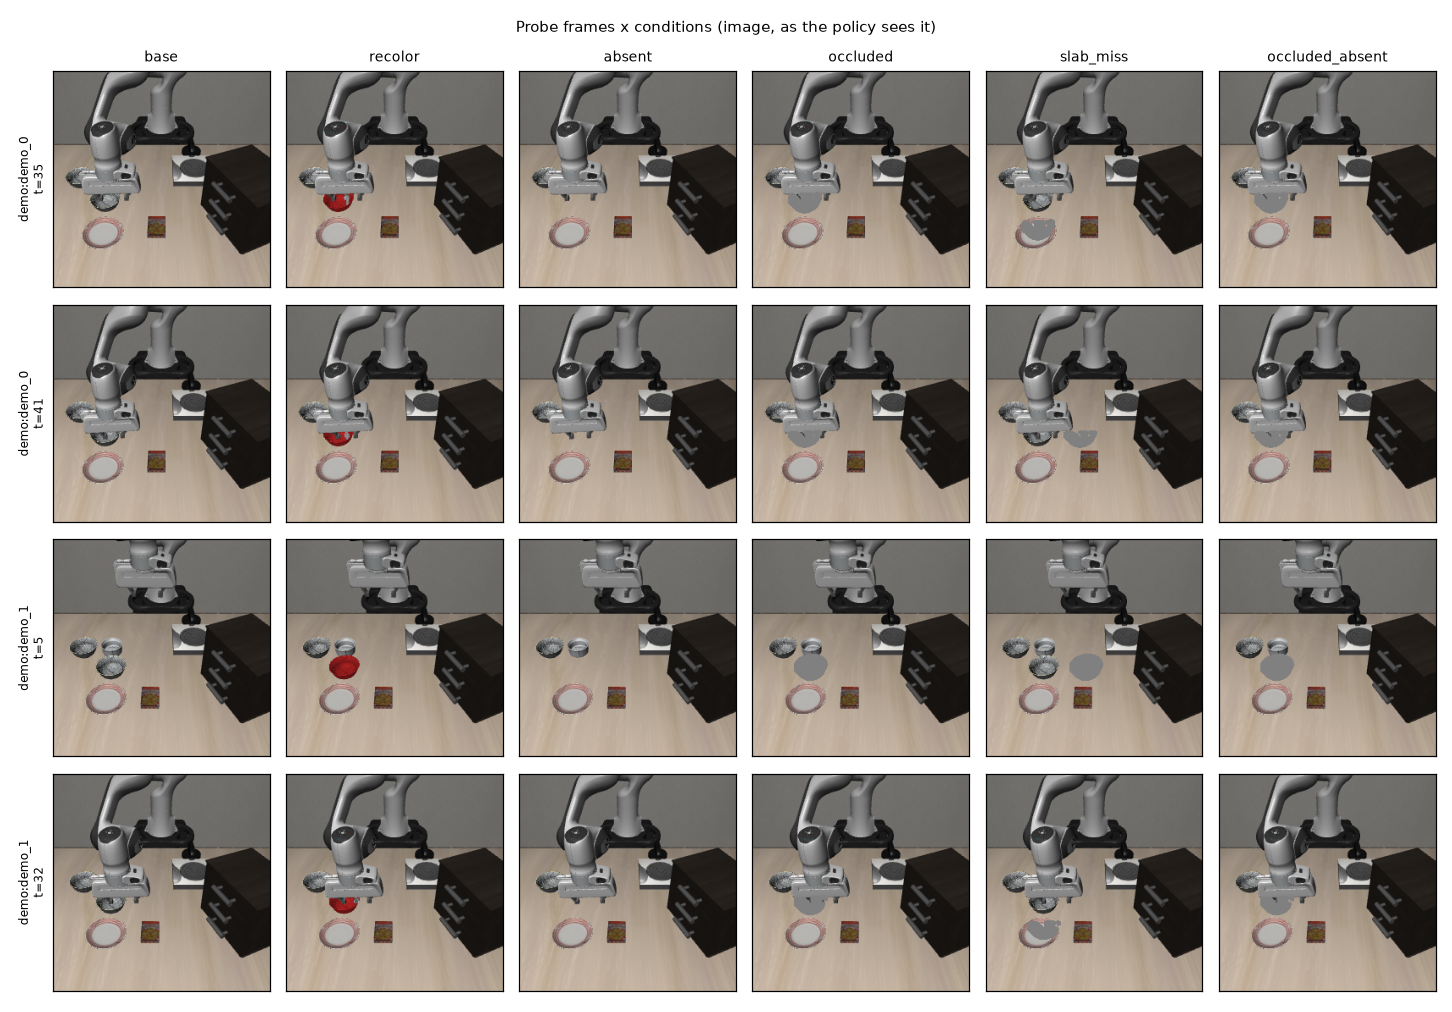

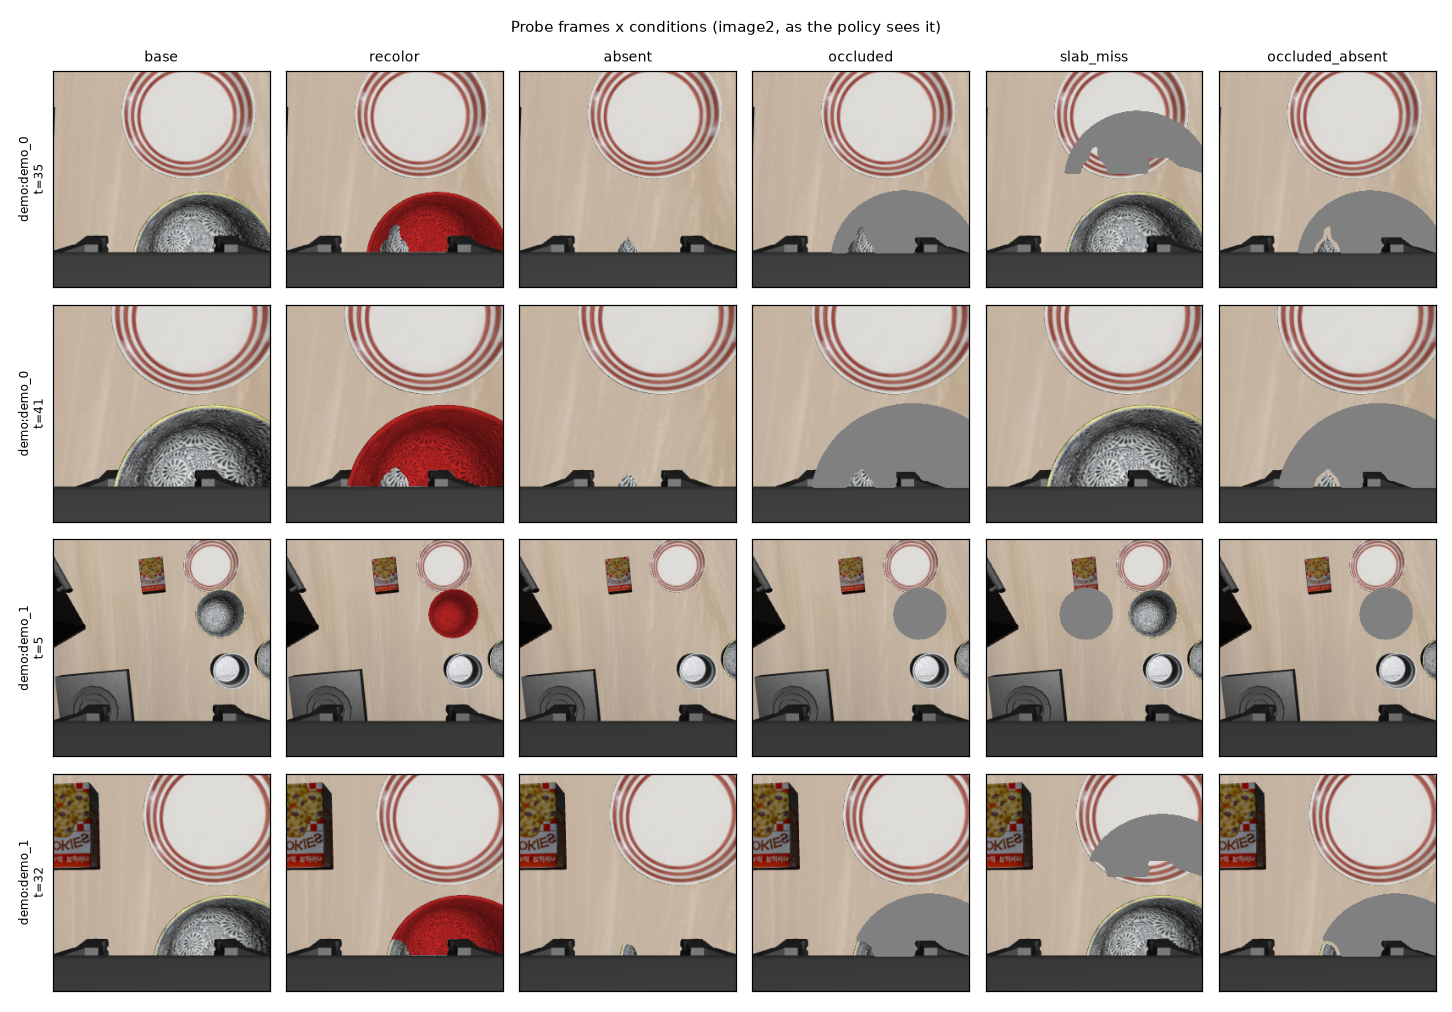

In [18]:
# @title Step 1: Probe frames and the 6 conditions

st = run_tc("frames")
banner("Probe frames", st)
if st:
    for p in st["probe"]:
        info = p["edit_info"]["image"]
        print(f"frame {p['frame_id']}: {p['episode']} t={p['t']} | bowl px (agentview)={info['mask_px']} | "
              f"slab shift={info['slab_shift']} ({info['slab_tag']}) | masks from {p['mask_source']}")
show("fig_probe_conditions_agentview.png", "fig_probe_conditions_wrist.png")

### Validate the setup BEFORE Goal 1 (the "instrument is not broken" test)
Checks 1–4 on the **unpatched** pipeline. If checks 1–4 pass, a null at Goal 1/2 is a *finding*; if any fails, a null is just *your bug*.

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py validate --out /content/groot-run/outputs/permanence/tc_circuit
[04:31:44] == validate | out=/content/groot-run/outputs/permanence/tc_circuit
[04:31:49] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned
✓ Loaded state dict from model.safetensors
All keys loaded successfully!
/content/lerobot-venv/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[04:34:18] policy loaded in 149s | dtype=bfloat16 chunk=50 n_action_steps=50 image_features=['observation.images.image', 'observat

### Validation (checks 1–4): **PASS**

1. Edits are clean       PASS
2. Determinism           PASS
3. The signal exists     PASS
4. The ceiling works     PASS
LLM layers found: 18 | best full-layer swap: 91.8% at layer 3
base-vs-occluded RMSE per frame: 0.5197, 0.5158, 0.6665, 0.5219


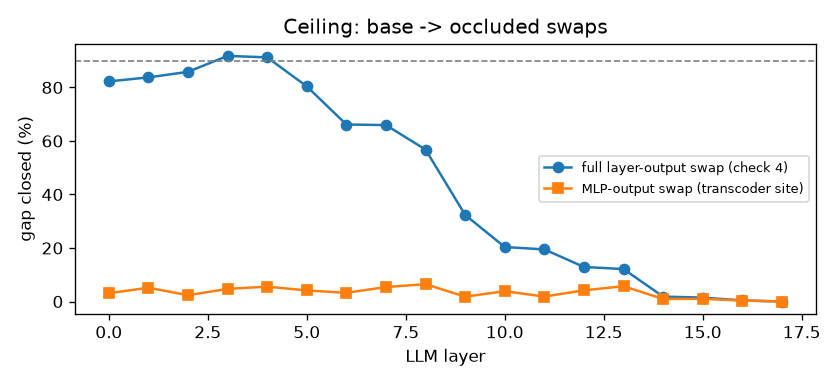

In [19]:
# @title Validate the setup BEFORE Goal 1: checks 1–4 on the unpatched pipeline

st = run_tc("validate")
banner("Validation (checks 1–4)", st)
if st:
    for k, label in (("check1", "1. Edits are clean"), ("check2", "2. Determinism"), ("check3", "3. The signal exists"),
                     ("check4", "4. The ceiling works")):
        print(f"{label:24s} {'PASS' if st[k] else 'FAIL'}")
    print(f"LLM layers found: {st['n_layers']} | best full-layer swap: {st['ceiling_best_pct']:.1f}% at layer {st['ceiling_best_layer']}")
    print("base-vs-occluded RMSE per frame:", ", ".join(f"{g:.4f}" for g in st["gaps"]))
show("fig_check4_ceiling.png")
if st and not st["passed"]:
    display(Markdown("**Rule of thumb:** a check failed, so any null result downstream would just be a bug. "
                     "Fix it before Goal 1 (check 3: pick other frames; check 4: hook/layer selection)."))

### Transcoders (check 5)
This cell captures MLP input/output at every LLM layer, on all valid prefix tokens (both cameras + prompt), for 4 frames × 6 conditions plus extra unedited frames. It then trains one TopK transcoder per layer and scores it on held-out tokens. The splice test swaps each MLP for its transcoder and reports the action error as a fraction of the occlusion gap.

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py capture --out /content/groot-run/outputs/permanence/tc_circuit
[04:50:17] == capture | out=/content/groot-run/outputs/permanence/tc_circuit
[04:50:22] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned
✓ Loaded state dict from model.safetensors
All keys loaded successfully!
/content/lerobot-venv/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[04:52:51] policy loaded in 149s | dtype=bfloat16 chunk=50 n_action_steps=50 image_features=['observation.images.image', 'observatio

### Check 5: transcoders are faithful: **PASS**

median held-out FVU = 0.1739 (plan: ~0.06; threshold 0.2)


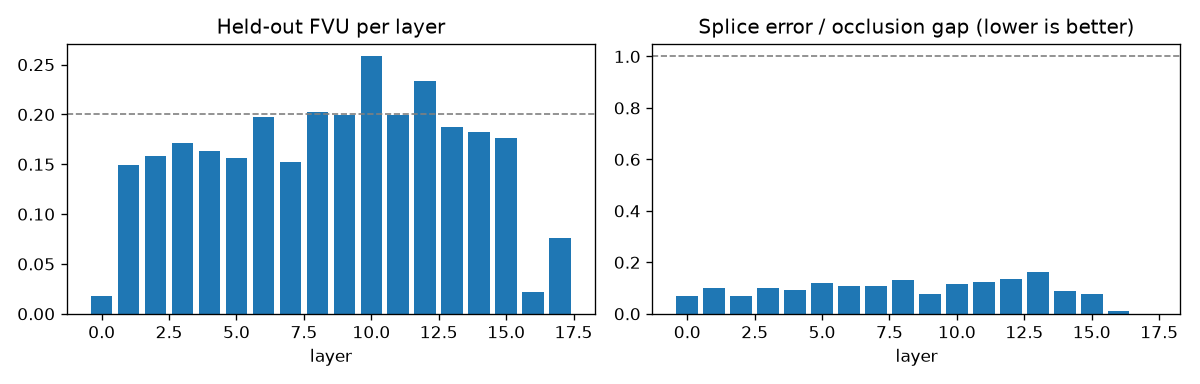

In [23]:
# @title Transcoders: capture activations, train one per layer (check 5)

run_tc("capture")
st = run_tc("train")
banner("Check 5: transcoders are faithful", st)
if st:
    print(f"median held-out FVU = {st['median_fvu']:.4f} (plan: ~0.06; threshold {TC_MAX_FVU})")
show("fig_check5_transcoders.png")

### Goal 1: Do occlusion features exist?
Feature activations are summed over tokens. Δ is measured against `base` per frame. A feature is kept when Δ_occluded > 0 on every frame, specificity = 1 − max(|Δ_recolor|, |Δ_absent|, |Δ_slab_miss|) / Δ_occluded ≥ 0.5, and the rise is at least one typical token-firing. **Kill switch:** if no layer has any passing feature, stop here.

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py goal1 --out /content/groot-run/outputs/permanence/tc_circuit
[05:00:02] == goal1 | out=/content/groot-run/outputs/permanence/tc_circuit
[05:00:04] layer  0:   4 passing occlusion features | top [274, 396, 415, 269] | color set [372, 4, 347, 118]
[05:00:05] layer  1:   3 passing occlusion features | top [69, 241, 4] | color set [492, 331, 341]
[05:00:05] layer  2:   3 passing occlusion features | top [296, 356, 210] | color set [289, 345, 236]
[05:00:05] layer  3:   4 passing occlusion features | top [76, 445, 503, 510] | color set [356, 308, 194, 172]
[05:00:05] layer  4:   8 passing occlusion features | top [112, 317, 397, 59, 158, 333, 359, 150] | color set [20, 392, 283, 445, 256, 257, 92, 476]
[05:00:06] layer  5:   6 passing occlusion features | top [318, 177, 505, 270, 32, 124] | color set [388, 338, 11, 197, 438, 360]
[05:00:06] layer  6:   6 passing occlusion features | top [71, 203, 78, 163, 295, 

### Goal 1: **PASS**

passing features per layer: {'0': 4, '1': 3, '2': 3, '3': 4, '4': 8, '5': 6, '6': 6, '7': 6, '8': 2, '9': 2, '10': 5, '11': 4, '12': 2, '13': 2, '14': 7, '15': 2, '16': 2, '17': 4}
top layers: [5, 0, 4] | selected features: {'5': [318, 177, 505, 270, 32, 124], '0': [274, 396, 415, 269], '4': [112, 317, 397, 59, 158, 333, 359, 150]}
feature table: /content/groot-run/outputs/permanence/tc_circuit/goal1_feature_table.csv


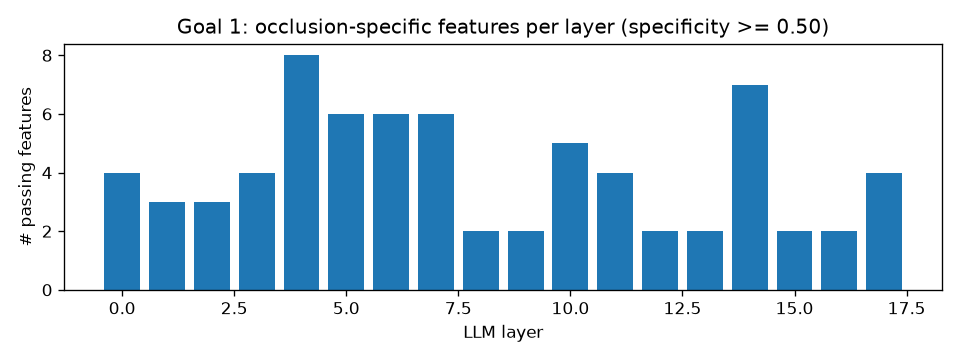

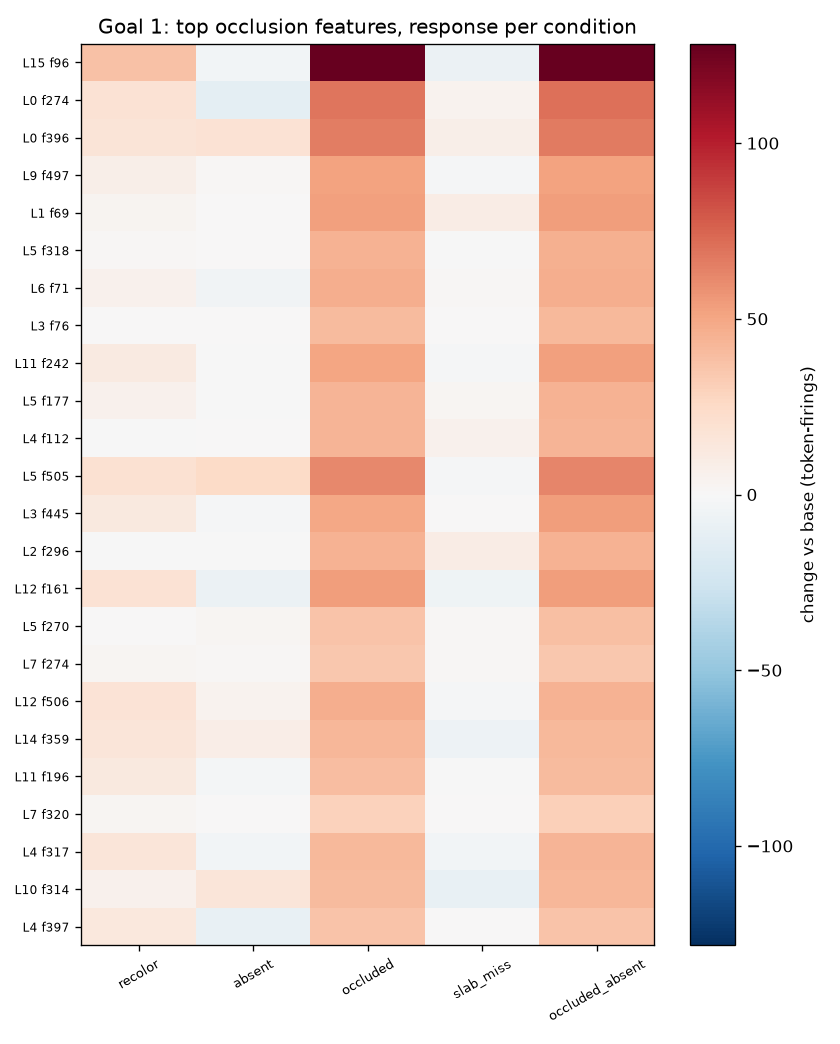

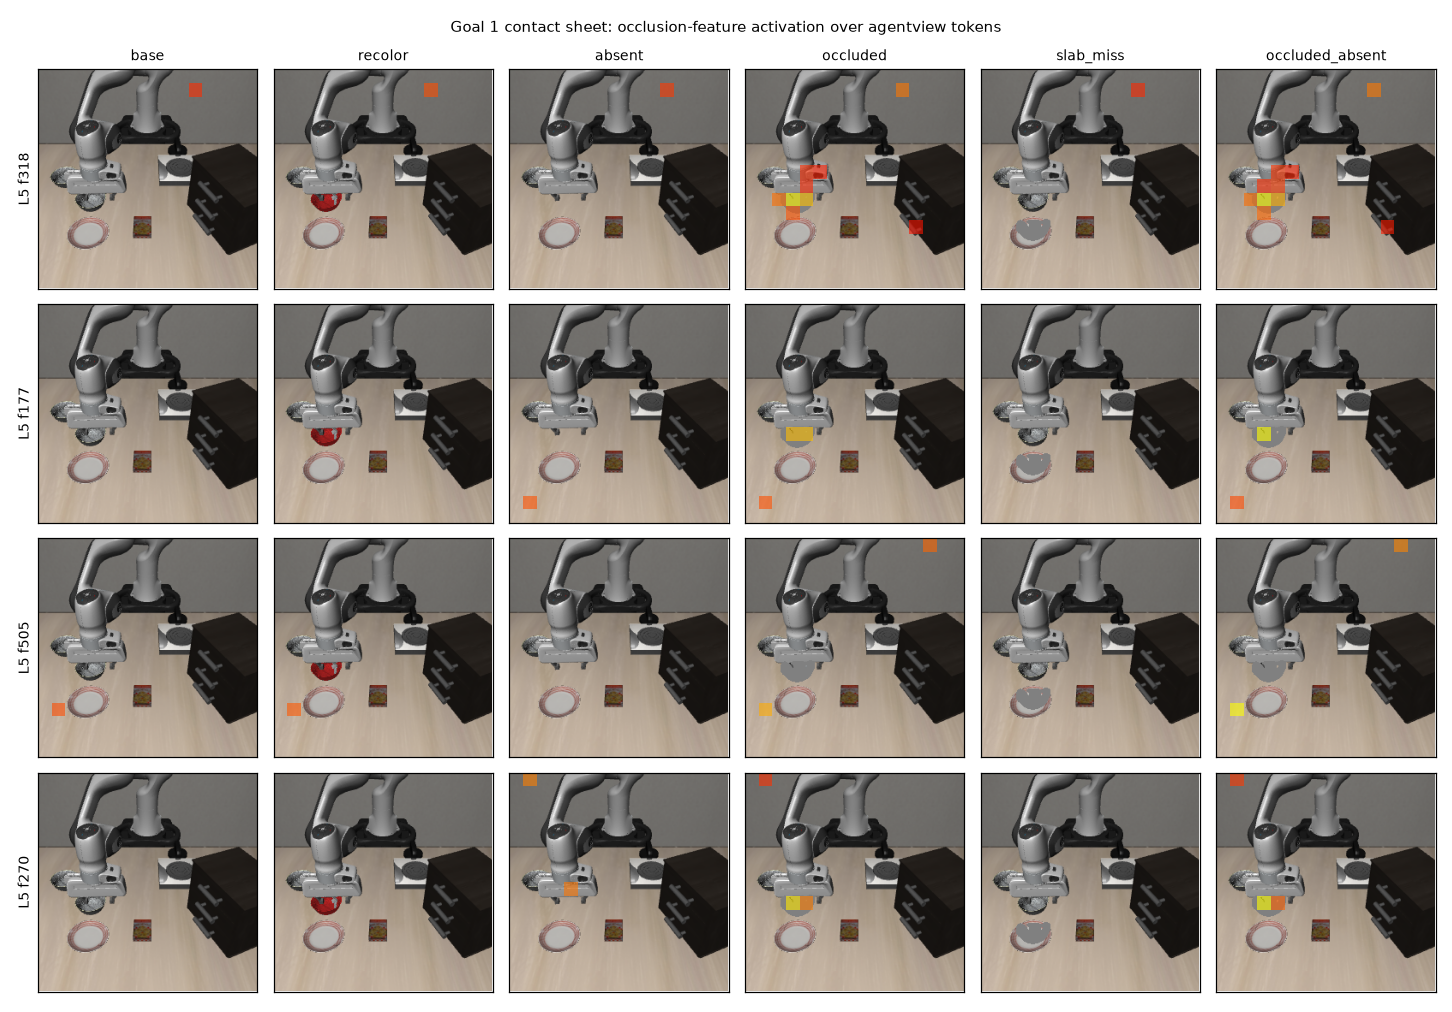

In [24]:
# @title Goal 1: Do occlusion features exist?

st = run_tc("goal1")
banner("Goal 1", st)
if st:
    print("passing features per layer:", st["n_pass_per_layer"])
    print("top layers:", st["top_layers"], "| selected features:", st["selected"])
    print("feature table:", TC_OUT / "goal1_feature_table.csv")
show("fig_goal1_counts.png", "fig_goal1_features.png", "fig_goal1_contact_sheet.png")

### Goal 2: Do they cause the action?
For the top layers from Goal 1, hook the MLP output and set **only** the occlusion features to their occluded-run values (the transcoder error term is kept). Controls: random features with the same per-token norm, raw random features, color features, all transcoder features, the MLP-output swap, and the full-token (layer-output) swap ceiling. Token structure is tested by patching all tokens, bowl tokens only, or everything except the bowl. **Pass:** occlusion features close ≥ 10 pts more than random *and* than color.

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py goal2 --out /content/groot-run/outputs/permanence/tc_circuit
[05:16:18] == goal2 | out=/content/groot-run/outputs/permanence/tc_circuit
[05:16:23] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned
✓ Loaded state dict from model.safetensors
All keys loaded successfully!
/content/lerobot-venv/lib/python3.12/site-packages/torch/jit/_script.py:365: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
[05:18:51] policy loaded in 149s | dtype=bfloat16 chunk=50 n_action_steps=50 image_features=['observation.images.image', 'observation.im

### Goal 2: **FAIL**  
occlusion features do not beat random/color by the margin at any site (single layers or all layers) -> Goal 2's null is the finding; skip Goal 3

layer 5: occlusion 1.9% | random same-norm 0.3% | color 0.5% | margin +1.5 pts -> fail
layer 0: occlusion 0.2% | random same-norm 0.3% | color 0.4% | margin -0.2 pts -> fail
layer 4: occlusion 1.2% | random same-norm 0.2% | color 0.2% | margin +0.9 pts -> fail
layer all: occlusion 3.9% | random same-norm 0.6% | color 0.7% | margin +3.3 pts -> fail


#### Circuit-trace table (main result)
| layer | method | scope | direction | gap closed % (mean ± sd) | n |
|---|---|---|---|---|---|
| all-layers | all_tc_features | all | inject | 40.1 ± 17.6 | 4 |
| all-layers | color_features | all | inject | 0.7 ± 1.2 | 4 |
| all-layers | mlp_swap_ceiling | all | inject | 65.5 ± 20.7 | 4 |
| all-layers | mlp_swap_ceiling | bowl | inject | 20.2 ± 13.4 | 4 |
| all-layers | mlp_swap_ceiling | nonbowl | inject | 29.4 ± 8.3 | 4 |
| all-layers | occ_features | all | inject | 3.9 ± 3.5 | 4 |
| all-layers | occ_features | bowl | inject | 3.1 ± 3.0 | 4 |
| all-layers | occ_features | nonbowl | inject | 1.0 ± 0.8 | 4 |
| all-layers | random_raw | all | inject | 0.5 ± 1.0 | 20 |
| all-layers | random_same_norm | all | inject | 0.6 ± 1.0 | 20 |
| all-layers | color_features | all | remove | 3.0 ± 4.3 | 4 |
| all-layers | mlp_swap_ceiling | all | remove | 85.6 ± 11.4 | 4 |
| all-layers | occ_features | all | remove | 7.9 ± 10.8 | 4 |
| top-all | occ_features_all_top_layers | all | inject | 2.5 ± 2.2 | 4 |
| 0 | all_tc_features | all | inject | 2.6 ± 2.1 | 4 |
| 0 | all_tc_features | bowl | inject | 1.4 ± 1.4 | 4 |
| 0 | all_tc_features | nonbowl | inject | 1.2 ± 0.7 | 4 |
| 0 | color_features | all | inject | 0.4 ± 0.7 | 4 |
| 0 | color_features | bowl | inject | 0.1 ± 0.1 | 4 |
| 0 | color_features | nonbowl | inject | 0.4 ± 0.7 | 4 |
| 0 | full_token_swap_ceiling | all | inject | 82.3 ± 25.0 | 4 |
| 0 | full_token_swap_ceiling | bowl | inject | 28.9 ± 25.5 | 4 |
| 0 | full_token_swap_ceiling | nonbowl | inject | 21.7 ± 12.3 | 4 |
| 0 | mlp_swap_ceiling | all | inject | 3.1 ± 2.4 | 4 |
| 0 | mlp_swap_ceiling | bowl | inject | 1.4 ± 1.7 | 4 |
| 0 | mlp_swap_ceiling | nonbowl | inject | 1.3 ± 0.8 | 4 |
| 0 | occ_features | all | inject | 0.2 ± 0.2 | 4 |
| 0 | occ_features | bowl | inject | 0.7 ± 0.9 | 4 |
| 0 | occ_features | nonbowl | inject | -0.0 ± 0.1 | 4 |
| 0 | random_raw | all | inject | 0.2 ± 0.6 | 20 |
| 0 | random_raw | bowl | inject | 0.2 ± 0.4 | 20 |
| 0 | random_raw | nonbowl | inject | 0.3 ± 0.8 | 20 |
| 0 | random_same_norm | all | inject | 0.3 ± 0.6 | 20 |
| 0 | random_same_norm | bowl | inject | 0.3 ± 0.6 | 20 |
| 0 | random_same_norm | nonbowl | inject | 0.4 ± 0.9 | 20 |
| 0 | single_feature_269 | all | inject | 0.5 ± 0.7 | 4 |
| 0 | single_feature_274 | all | inject | 0.2 ± 0.3 | 4 |
| 0 | single_feature_396 | all | inject | -0.1 ± 0.2 | 4 |
| 0 | single_feature_415 | all | inject | 0.5 ± 0.7 | 4 |
| 0 | color_features | all | remove | 4.7 ± 8.1 | 4 |
| 0 | mlp_swap_ceiling | all | remove | 16.1 ± 14.5 | 4 |
| 0 | occ_features | all | remove | 9.4 ± 15.4 | 4 |
| 4 | all_tc_features | all | inject | 3.5 ± 1.9 | 4 |
| 4 | all_tc_features | bowl | inject | 2.0 ± 1.9 | 4 |
| 4 | all_tc_features | nonbowl | inject | 2.5 ± 1.7 | 4 |
| 4 | color_features | all | inject | 0.2 ± 0.3 | 4 |
| 4 | color_features | bowl | inject | 0.4 ± 0.7 | 4 |
| 4 | color_features | nonbowl | inject | 0.3 ± 0.5 | 4 |
| 4 | full_token_swap_ceiling | all | inject | 91.3 ± 5.4 | 4 |
| 4 | full_token_swap_ceiling | bowl | inject | 22.2 ± 15.0 | 4 |
| 4 | full_token_swap_ceiling | nonbowl | inject | 28.9 ± 20.0 | 4 |
| 4 | mlp_swap_ceiling | all | inject | 5.6 ± 2.7 | 4 |
| 4 | mlp_swap_ceiling | bowl | inject | 2.4 ± 2.3 | 4 |
| 4 | mlp_swap_ceiling | nonbowl | inject | 3.8 ± 1.9 | 4 |
| 4 | occ_features | all | inject | 1.2 ± 1.0 | 4 |
| 4 | occ_features | bowl | inject | 0.7 ± 0.7 | 4 |
| 4 | occ_features | nonbowl | inject | 0.1 ± 0.6 | 4 |
| 4 | random_raw | all | inject | 0.2 ± 0.4 | 20 |
| 4 | random_raw | bowl | inject | 0.2 ± 0.4 | 20 |
| 4 | random_raw | nonbowl | inject | 0.3 ± 0.5 | 20 |
| 4 | random_same_norm | all | inject | 0.2 ± 0.6 | 20 |
| 4 | random_same_norm | bowl | inject | 0.2 ± 0.6 | 20 |
| 4 | random_same_norm | nonbowl | inject | 0.1 ± 0.4 | 20 |
| 4 | single_feature_112 | all | inject | 0.1 ± 0.3 | 4 |
| 4 | single_feature_150 | all | inject | 0.4 ± 0.7 | 4 |
| 4 | single_feature_158 | all | inject | 0.6 ± 0.7 | 4 |
| 4 | single_feature_317 | all | inject | 0.1 ± 0.1 | 4 |
| 4 | single_feature_333 | all | inject | 0.0 ± 0.1 | 4 |
| 4 | single_feature_359 | all | inject | 0.4 ± 0.6 | 4 |
| 4 | single_feature_397 | all | inject | 0.3 ± 0.3 | 4 |
| 4 | single_feature_59 | all | inject | 0.6 ± 0.6 | 4 |
| 4 | color_features | all | remove | -1.1 ± 1.7 | 4 |
| 4 | mlp_swap_ceiling | all | remove | 23.9 ± 15.3 | 4 |
| 4 | occ_features | all | remove | -1.6 ± 6.0 | 4 |
| 5 | all_tc_features | all | inject | 4.0 ± 2.2 | 4 |
| 5 | all_tc_features | bowl | inject | 2.0 ± 1.6 | 4 |
| 5 | all_tc_features | nonbowl | inject | 2.2 ± 1.5 | 4 |
| 5 | color_features | all | inject | 0.5 ± 0.7 | 4 |
| 5 | color_features | bowl | inject | 0.5 ± 0.7 | 4 |
| 5 | color_features | nonbowl | inject | 0.3 ± 0.4 | 4 |
| 5 | full_token_swap_ceiling | all | inject | 80.4 ± 20.7 | 4 |
| 5 | full_token_swap_ceiling | bowl | inject | 18.6 ± 11.9 | 4 |
| 5 | full_token_swap_ceiling | nonbowl | inject | 28.6 ± 20.0 | 4 |
| 5 | mlp_swap_ceiling | all | inject | 4.1 ± 3.3 | 4 |
| 5 | mlp_swap_ceiling | bowl | inject | 1.8 ± 1.5 | 4 |
| 5 | mlp_swap_ceiling | nonbowl | inject | 2.7 ± 2.6 | 4 |
| 5 | occ_features | all | inject | 1.9 ± 2.3 | 4 |
| 5 | occ_features | bowl | inject | 1.3 ± 1.6 | 4 |
| 5 | occ_features | nonbowl | inject | 0.8 ± 1.0 | 4 |
| 5 | random_raw | all | inject | 0.3 ± 0.7 | 20 |
| 5 | random_raw | bowl | inject | 0.1 ± 0.4 | 20 |
| 5 | random_raw | nonbowl | inject | 0.4 ± 0.8 | 20 |
| 5 | random_same_norm | all | inject | 0.3 ± 0.6 | 20 |
| 5 | random_same_norm | bowl | inject | 0.4 ± 0.8 | 20 |
| 5 | random_same_norm | nonbowl | inject | 0.3 ± 0.6 | 20 |
| 5 | single_feature_124 | all | inject | 1.1 ± 1.2 | 4 |
| 5 | single_feature_177 | all | inject | 0.0 ± 0.1 | 4 |
| 5 | single_feature_270 | all | inject | 0.2 ± 0.3 | 4 |
| 5 | single_feature_318 | all | inject | 0.8 ± 1.4 | 4 |
| 5 | single_feature_32 | all | inject | 0.0 ± 0.3 | 4 |
| 5 | single_feature_505 | all | inject | 0.9 ± 1.3 | 4 |
| 5 | color_features | all | remove | -1.1 ± 2.2 | 4 |
| 5 | mlp_swap_ceiling | all | remove | 22.5 ± 16.2 | 4 |
| 5 | occ_features | all | remove | 8.4 ± 12.0 | 4 |


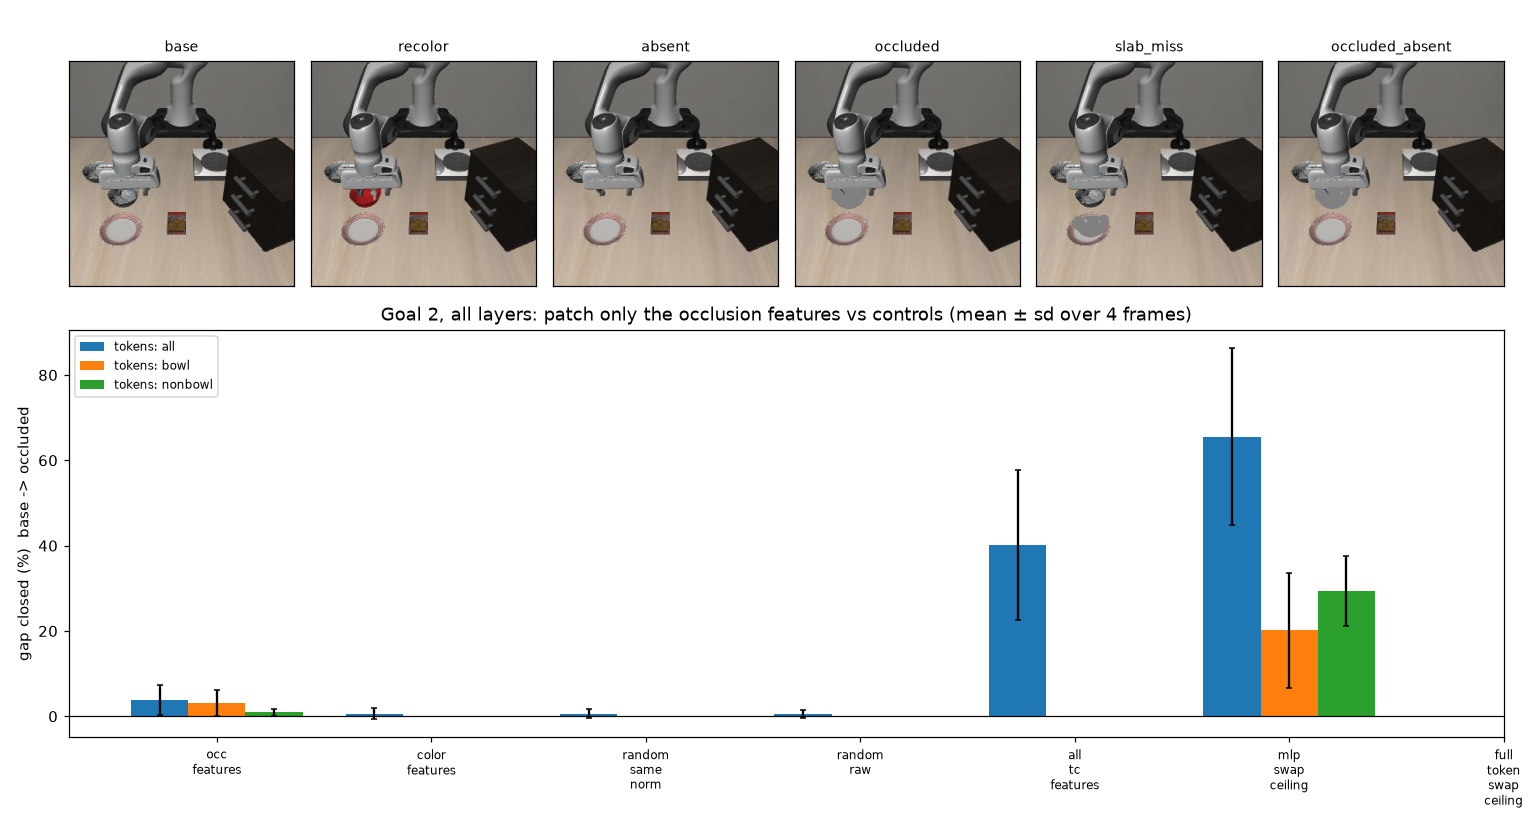

In [28]:
# @title Goal 2: Do they cause the action? (transcoder + circuit-tracing core)

st = run_tc("goal2")
banner("Goal 2", st)
if st:
    for layer, v in st["verdict"].items():
        print(f"layer {layer}: occlusion {v['occ']:.1f}% | random same-norm {v['random_same_norm']:.1f}% | "
              f"color {v['color']:.1f}% | margin {v['margin_vs_best_control']:+.1f} pts -> {'PASS' if v['passed'] else 'fail'}")
md = TC_OUT / "goal2_circuit_trace_table.md"
if md.exists():
    display(Markdown("#### Circuit-trace table (main result)\n" + md.read_text()))
show("fig_goal2_contact_sheet.png")

### Goal 3: Do they change task success?
Closed-loop LIBERO with the bowl painted gray in both cameras on every step. Conditions are baseline / features ablated (×0) / features amplified (×`AMPLIFY_FACTOR`), plus an unoccluded clean reference, all sharing the same init states and seeds. Check 6 runs first. **Pass:** the success rate shifts in the predicted direction (paired bootstrap CI excludes zero). Otherwise the result is a quantified null.

In [29]:
# @title Goal 3: Do they change task success? (check 6 first)

st = run_tc("goal3")
banner("Goal 3", st)
if st:
    print("check 6 (baseline success strictly between 0% and 100%):", "PASS" if st["check6"] else "FAIL")
    print("success rates:", {k: round(v, 2) for k, v in st["success"].items()})
    for name, s in st["stats"].items():
        print(f"{name}: diff vs baseline {s['diff_vs_baseline']:+.2f}, CI95 [{s['ci95'][0]:+.2f}, {s['ci95'][1]:+.2f}], "
              f"predicted sign {s['predicted_sign']} -> {'shift' if s['ci_excludes_zero_in_predicted_direction'] else 'no reliable shift'}")
show("fig_goal3_success.png")
vids = sorted((TC_OUT / "videos").glob("*.mp4")) if (TC_OUT / "videos").exists() else []
if vids:
    print("videos:", *[str(v) for v in vids], sep="\n  ")

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py goal3 --out /content/groot-run/outputs/permanence/tc_circuit
[05:27:50] == goal3 | out=/content/groot-run/outputs/permanence/tc_circuit
[gate] goal2 did not pass, so Goal 3 is stopped (plan's gate rule). Reason: occlusion features do not beat random/color by the margin at any site (single layers or all layers) -> Goal 2's null is the finding; skip Goal 3. Set FORCE_CONTINUE=True to run anyway.


RuntimeError: [gate] goal2 did not pass, so Goal 3 is stopped (plan's gate rule). Reason: occlusion features do not beat random/color by the margin at any site (single layers or all layers) -> Goal 2's null is the finding; skip Goal 3. Set FORCE_CONTINUE=True to run anyway.
(Stopped by the plan's gate rule. This is an outcome, not a crash.)

In [30]:
# @title Summary: checks, goals, and the one-line pitch

rows = []
v = tc_status("validate") or {}
t = tc_status("train") or {}
g1, g2, g3 = tc_status("goal1"), tc_status("goal2"), tc_status("goal3")
fmt = lambda x: "PASS" if x is True else ("FAIL" if x is False else "not run")
rows += [("Check 1: edits are clean", fmt(v.get("check1"))), ("Check 2: determinism", fmt(v.get("check2"))),
         ("Check 3: the signal exists", fmt(v.get("check3"))), ("Check 4: the ceiling works", fmt(v.get("check4"))),
         ("Check 5: transcoder is faithful", fmt(t.get("check5"))),
         ("Goal 1: occlusion features exist", fmt(g1 and g1.get("passed"))),
         ("Goal 2: they cause the action", fmt(g2 and g2.get("passed"))),
         ("Check 6: closed loop measurable", fmt(g3 and g3.get("check6"))),
         ("Goal 3: task success shifts", fmt(g3 and g3.get("passed")))]
display(Markdown("| item | result |\n|---|---|\n" + "\n".join(f"| {a} | {b} |" for a, b in rows)))

checks_ok = all(v.get(k) for k in ("check1", "check2", "check3", "check4"))
if g1 and g1.get("passed") is False:
    verdict = ("Negative result: no sparse occlusion features exist in π0.5; the signal is diffuse."
               + (" Checks 1–4 passed, so this is a finding." if checks_ok else " Checks 1–4 did not all pass, so treat this as a possible bug."))
elif g2 and g2.get("passed") is False:
    verdict = ("Goal 2 null: occlusion features exist but do not beat random/color features at moving the action. "
               "This null is the finding (first transcoder circuit tracing on a VLA, negative).")
elif g2 and g2.get("passed"):
    best = g2["best_layer"]
    occ = g2["verdict"][str(best)]["occ"] if str(best) in g2["verdict"] else float("nan")
    verdict = (f"Positive: occlusion features at layer(s) {g2['passing_layers']} close {occ:.0f}% of the base→occluded action gap "
               f"(margin {g2['verdict'][str(best)]['margin_vs_best_control']:+.0f} pts over controls).")
    if g3:
        verdict += (" Closed loop: " + ("success shifts in the predicted direction." if g3.get("passed") else
                    "the causal effect does not survive closed loop (quantified null)."))
else:
    verdict = "Pipeline not finished yet."
display(Markdown(f"**Verdict:** {verdict}"))
display(Markdown('**One-line pitch if it works out:** *"First transcoder-based circuit tracing on a vision-language-action model: '
                 'occlusion-specific features in π0.5\'s LLM backbone, causally tested on the action and in closed loop on LIBERO."* '
                 "VLA-Trace (attention knockout) and the SAE-VLA papers (no circuit tracing) are the prior work you differentiate from."))
print("All outputs:", TC_OUT, "| Drive mirror:", DRIVE_TC)

| item | result |
|---|---|
| Check 1: edits are clean | PASS |
| Check 2: determinism | PASS |
| Check 3: the signal exists | PASS |
| Check 4: the ceiling works | PASS |
| Check 5: transcoder is faithful | PASS |
| Goal 1: occlusion features exist | PASS |
| Goal 2: they cause the action | FAIL |
| Check 6: closed loop measurable | not run |
| Goal 3: task success shifts | not run |

**Verdict:** Goal 2 null: occlusion features exist but do not beat random/color features at moving the action. This null is the finding (first transcoder circuit tracing on a VLA, negative).

**One-line pitch if it works out:** *"First transcoder-based circuit tracing on a vision-language-action model: occlusion-specific features in π0.5's LLM backbone, causally tested on the action and in closed loop on LIBERO."* VLA-Trace (attention knockout) and the SAE-VLA papers (no circuit tracing) are the prior work you differentiate from.

All outputs: /content/groot-run/outputs/permanence/tc_circuit | Drive mirror: /content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit


In [ ]:
# @title Download everything: one zip to your computer (+ a copy on Drive)

import json
import os
import shutil
import subprocess
import time
import zipfile
from pathlib import Path

INCLUDE_TRANSCODERS = True  # @param {type:"boolean"}
INCLUDE_PROBE_FRAMES = True  # @param {type:"boolean"}
INCLUDE_ACTIVATION_CACHE = False  # @param {type:"boolean"}
COPY_ZIP_TO_DRIVE = True  # @param {type:"boolean"}

# ---------------------------------------------------------------- locate everything (works after a runtime reset too)
g = globals()
out = Path(g.get("TC_OUT", "/content/groot-run/outputs/permanence/tc_circuit"))
drive_tc = Path(g.get("DRIVE_TC", "/content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit"))
if not (out / "status").exists() and (drive_tc / "status").exists():
    print("Local results not found; using the Drive mirror:", drive_tc)
    out = drive_tc
if not (out / "status").exists():
    raise FileNotFoundError(f"No results found in {out} or {drive_tc}. Run the pipeline cells first.")
script = Path(g.get("TC_SCRIPT", "/content/groot-run/scripts/tc_occlusion.py"))
python = str(g.get("PYTHON", "/content/lerobot-venv/bin/python"))

stamp = time.strftime("%Y%m%d_%H%M")
name = f"tc_circuit_results_{stamp}"
bundle = Path("/content") / name
if bundle.exists():
    shutil.rmtree(bundle)
(bundle / "results").mkdir(parents=True)
(bundle / "code").mkdir()
(bundle / "env").mkdir()

# ---------------------------------------------------------------- 1. results (figures, tables, statuses, transcoders, frames)
skip = set()
if not INCLUDE_ACTIVATION_CACHE:
    skip.add("acts")
if not INCLUDE_TRANSCODERS:
    skip.add("transcoders")


def _ignore(dirpath, names):
    ign = [n for n in names if Path(dirpath) == out and n in skip]
    if not INCLUDE_PROBE_FRAMES and Path(dirpath) == out:
        ign += [n for n in names if n == "frames.pkl"]
    return ign


shutil.copytree(out, bundle / "results", dirs_exist_ok=True, ignore=_ignore)

# ---------------------------------------------------------------- 2. code: pipeline script, config, this notebook
if script.exists():
    shutil.copy2(script, bundle / "code" / "tc_occlusion.py")
if (out / "config.json").exists():
    shutil.copy2(out / "config.json", bundle / "code" / "config.json")
try:
    from google.colab import _message

    nb = _message.blocking_request("get_ipynb", timeout_sec=60)["ipynb"]
    (bundle / "code" / "notebook.ipynb").write_text(json.dumps(nb, indent=1))
    print("saved the notebook (with outputs) into the bundle")
except Exception as exc:
    print(f"could not export the notebook itself ({type(exc).__name__}); use File -> Download -> .ipynb for it")

# ---------------------------------------------------------------- 3. environment (for reproducibility)
def _run(cmd):
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        return (r.stdout or "") + (r.stderr or "")
    except Exception as exc:
        return f"{cmd}: {exc}"


(bundle / "env" / "packages.txt").write_text(_run([python, "-c",
    "import importlib.metadata as m; print('\\n'.join(sorted(f\"{d.metadata['Name']}=={d.version}\" for d in m.distributions())))"]))
(bundle / "env" / "versions.txt").write_text(_run([python, "-c",
    "import sys, lerobot, transformers, torch, numpy, mujoco; print('python', sys.version); "
    "print('lerobot', lerobot.__version__); print('transformers', transformers.__version__); "
    "print('torch', torch.__version__, 'cuda', torch.version.cuda); print('numpy', numpy.__version__); print('mujoco', mujoco.__version__)"]))
(bundle / "env" / "gpu.txt").write_text(_run(["nvidia-smi"]))

# ---------------------------------------------------------------- 4. RESULTS.md: every number that matters, in one page
def _st(step):
    p = out / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def _f(x, nd=1):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "n/a"


pf = lambda x: "PASS" if x is True else ("FAIL" if x is False else "not run")
v, t, g1, g2, g3 = _st("validate") or {}, _st("train") or {}, _st("goal1"), _st("goal2"), _st("goal3")
fr = _st("frames") or {}
cfg = json.loads((out / "config.json").read_text()) if (out / "config.json").exists() else {}
L = [f"# Transcoder circuit tracing on π0.5 (LIBERO) — results", "",
     f"Bundle created {time.strftime('%Y-%m-%d %H:%M')} from `{out}`.", "",
     f"Policy `{cfg.get('policy_path', '?')}` · suite `{cfg.get('suite', '?')}` task {cfg.get('task_id', '?')} · "
     f"target `{fr.get('target_object', '?')}` · {fr.get('n_probe_frames', '?')} probe frames · "
     f"transcoders {cfg.get('tc_features', '?')} features, k={cfg.get('tc_k', '?')}, {cfg.get('tc_steps', '?')} steps", "",
     "## Checks and goals", "", "| item | result |", "|---|---|",
     f"| Check 1: edits are clean | {pf(v.get('check1'))} |", f"| Check 2: determinism | {pf(v.get('check2'))} |",
     f"| Check 3: the signal exists | {pf(v.get('check3'))} |", f"| Check 4: the ceiling works | {pf(v.get('check4'))} |",
     f"| Check 5: transcoder is faithful | {pf(t.get('check5'))} |",
     f"| Goal 1: occlusion features exist | {pf(g1 and g1.get('passed'))} |",
     f"| Goal 2: they cause the action | {pf(g2 and g2.get('passed'))} |",
     f"| Check 6: closed loop measurable | {pf(g3 and g3.get('check6'))} |",
     f"| Goal 3: task success shifts | {pf(g3 and g3.get('passed'))} |", ""]
if v:
    L += ["## Validation", "",
          f"- Base-vs-occluded action RMSE per frame: {', '.join(_f(x, 4) for x in v.get('gaps', []))}",
          f"- LLM layers: {v.get('n_layers')} · best full-layer swap (check 4): {_f(v.get('ceiling_best_pct'))}% at layer {v.get('ceiling_best_layer')}", ""]
if t:
    L += ["## Transcoders (check 5)", "", f"- Median held-out FVU: {_f(t.get('median_fvu'), 4)}",
          "- Per layer FVU: " + ", ".join(f"L{i}={_f(x, 3)}" for i, x in enumerate(t.get("fvu_per_layer", []))),
          "- Splice error / occlusion gap: " + ", ".join(f"L{i}={_f(x, 3)}" for i, x in enumerate(t.get("splice_over_gap", []))), ""]
if g1:
    L += ["## Goal 1", "", f"- Top layers: {g1.get('top_layers')}",
          f"- Passing features per layer: {g1.get('n_pass_per_layer')}",
          f"- Selected features (top layers): {g1.get('selected')}", ""]
if g2:
    L += ["## Goal 2 (gap closed, base → occluded, mean over frames)", "",
          "| site | occlusion features | random same-norm | random raw | color | MLP-site ceiling | occlusion as % of ceiling | margin vs best control | pass |",
          "|---|---|---|---|---|---|---|---|---|"]
    for site, s in g2.get("verdict", {}).items():
        L.append(f"| {'all layers' if site == 'all' else 'layer ' + site} | {_f(s.get('occ'))}% | {_f(s.get('random_same_norm'))}% | "
                 f"{_f(s.get('random_raw'))}% | {_f(s.get('color'))}% | {_f(s.get('mlp_site_ceiling'))}% | "
                 f"{_f(s.get('occ_share_of_ceiling_pct'))}% | {_f(s.get('margin_vs_best_control'))} pts | {pf(s.get('passed'))} |")
    L += ["", f"Rule: {g2.get('rule', 'absolute')} (+{cfg.get('goal2_margin_pts', 10)} pts over random and color). "
          f"Passing sites: {g2.get('passing_layers')}. {g2.get('reason', '')}", "",
          "Full table: `results/goal2_circuit_trace_table.md` (all methods, token scopes, reverse direction).", ""]
if g3:
    L += ["## Goal 3", "", f"- Success rates: {g3.get('success')}", f"- Stats: {json.dumps(g3.get('stats'))}", ""]
L += ["## Caveats to report", "",
      f"- {fr.get('n_probe_frames', 4)} probe frames: the error bars are wide.",
      "- The features respond equally to paint with or without the bowl underneath (`occluded` vs `occluded_absent`). "
      "π0.5 sees one frame at a time, so they are 'gray patch at the object location' features, not object permanence.",
      "- The all-layers Goal 2 site was added after the single-layer run (single-MLP ceilings were only 3–6%). "
      "Report the single-layer null under the original rule and the all-layers test as an extension.", "",
      "## What is in this bundle", "",
      "- `RESULTS.md`: this page.",
      "- `results/`: every figure (`fig_*.png`), table (`*.csv`, `*.md`), status JSON (`status/`), `validate.json`, `train.json`, "
      "`goal1_selected.json`, `goal2_edges.json`" + (", trained transcoders (`transcoders/layer_XX.pt`)" if INCLUDE_TRANSCODERS else "")
      + (", probe frames with all 6 renders (`frames.pkl`)" if INCLUDE_PROBE_FRAMES else "")
      + (", activation cache (`acts/`)" if INCLUDE_ACTIVATION_CACHE else "") + ".",
      "- `code/`: `tc_occlusion.py` (the whole pipeline), `config.json`, and `notebook.ipynb` if the export worked.",
      "- `env/`: package versions, GPU info.", "",
      "Re-run any step on a GPU box with: `python code/tc_occlusion.py <frames|validate|capture|train|goal1|goal2|goal3> --out results` "
      "(needs the same lerobot + LIBERO install; `capture` must run before `goal1` if `acts/` is not included)."]
(bundle / "RESULTS.md").write_text("\n".join(L) + "\n")

# ---------------------------------------------------------------- 5. zip + download (+ Drive copy)
zip_path = Path("/content") / f"{name}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as z:
    for p in sorted(bundle.rglob("*")):
        if p.is_file():
            z.write(p, arcname=str(Path(name) / p.relative_to(bundle)))
size_mb = zip_path.stat().st_size / 2**20
n_files = sum(1 for p in bundle.rglob("*") if p.is_file())
print(f"\nbundle: {zip_path}  ({size_mb:.1f} MB, {n_files} files)")
for sub in ("results", "code", "env"):
    mb = sum(p.stat().st_size for p in (bundle / sub).rglob("*") if p.is_file()) / 2**20
    print(f"  {sub:8s} {mb:8.1f} MB")

if COPY_ZIP_TO_DRIVE:
    try:
        dst = drive_tc.parent / zip_path.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(zip_path, dst)
        print("Drive copy:", dst)
    except Exception as exc:
        print(f"Drive copy failed ({type(exc).__name__}: {exc})")

try:
    from google.colab import files

    files.download(str(zip_path))
    print("download started in your browser")
except Exception as exc:
    print(f"browser download not available ({type(exc).__name__}); grab the zip from the Files panel or the Drive copy")